# Fairness, Robustesse, Interprétabilité & Incertitude — Medical Bios

Ce notebook implémente et analyse expérimentalement des méthodes liées à l'**équité algorithmique**, à la **robustesse** et à l'**interprétabilité** sur le jeu de données **Medical Bios** (coastalcph/medical-bios, HuggingFace).

| Élément | Détail |
|---------|--------|
| **Tâche** | Classification de professions médicales à partir de biographies textuelles |
| **Attribut sensible** | Genre (Male / Female) |
| **Modèle de base** | DistilBERT (embeddings CLS) + Régression Logistique |
| **Métrique de fairness** | Gap Recall (H−F) — critère *Equal Opportunity* |
| **Reproductibilité** | `SEED=42` fixé sur NumPy, PyTorch CPU et CUDA |

**Plan du notebook :**
1. **Preprocessing** — D0 → D1 (masquage profession) → D1n (+ neutralisation genre)
2. **Benchmark** — Performance globale sur D1 ; montrer que le modèle fonctionne avant de montrer qu'il est biaisé
3. **Inégalités** — Recall gap par profession × genre (surgeon♀ = 0.45, nurse♂ = 0.75)
4. **Robustesse architecturale** — Le biais est-il un artefact de DistilBERT ?
5. **Fairness / Mitigation** — Reweighing, Augmentation contrefactuelle, Combinaison
6. **Interprétabilité** - Comprnedre les décisions du modèle

7. **Incertitude & diagnostic du biais** — Tableau récapitulatif & recommandations


## Section 0 — Setup

### 0.0 — Environnement & Cache Google Drive

Les embeddings DistilBERT (768 dimensions, ~8 000 exemples) prennent ~15 min à extraire sur GPU T4.
Ils sont mis en cache dans Google Drive pour survivre aux redémarrages du runtime Colab.

> **Plateforme recommandée** : Google Colab avec GPU T4 ou A100.  
> En environnement local, le fallback utilise `./cache/fairness_nlp/`.


### 0.0 — Installation des dépendances

Versions fixées pour garantir la reproductibilité :
- `transformers==4.40.0` — encodeur DistilBERT (tokenizer + modèle)
- `scikit-learn==1.4.2` — Régression Logistique, métriques, LabelEncoder
- `datasets==2.19.0` — utilitaire HuggingFace (optionnel ici)


In [1]:
# ── Installation des dépendances ─────────────────────────────────────
# À exécuter en premier sur Google Colab (déjà présent sur la plupart des runtimes,
# mais cette cellule garantit les bonnes versions)
#!pip install -q "transformers==4.40.0" "scikit-learn==1.4.2" "datasets==2.19.0"

In [2]:
import os

# ── Google Drive (pour persister les embeddings entre les sessions) ──
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_DIR = "/content/drive/MyDrive/fairness_nlp"
    DATA_BASE = "/content"
except ImportError:
    # Environnement local ou non-Colab
    DRIVE_DIR = "./cache/fairness_nlp"
    DATA_BASE = "."
    print("ℹ️  Hors Colab — cache local dans ./cache/fairness_nlp")

os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"📁 Dossier cache : {DRIVE_DIR}")

Mounted at /content/drive
📁 Dossier cache : /content/drive/MyDrive/fairness_nlp


### 0.1 — Imports & Configuration

Imports des librairies principales et configuration de la reproductibilité :
- `SEED=42` fixé sur NumPy, PyTorch CPU et CUDA
- `torch.backends.cudnn.deterministic = True` pour les résultats déterministes sur GPU


In [3]:
import os
import json
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── Reproductibilité ─────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"PyTorch : {torch.__version__}")

Device : cuda
PyTorch : 2.10.0+cu128


### 0.2 — Chargement du Dataset Medical Bios

Le dataset est téléchargé depuis HuggingFace (`coastalcph/medical-bios`) et mis en cache localement.

Chaque exemple contient :
- `full_text` : biographie complète (avec pronoms, titres, prénom — sources de biais)
- `text` : version sans le prénom
- `title` : profession cible (dentist, nurse, physician, psychologist, surgeon)
- `gender` : Male / Female (attribut sensible)

Les fichiers sont au format JSONL (une ligne = un objet JSON).


In [4]:
import zipfile

# ── Téléchargement du dataset depuis HuggingFace ────────────────────
DATA_DIR = os.path.join(DATA_BASE, "medical_bios")
ZIP_PATH = os.path.join(DATA_BASE, "bios.zip")
HF_URL   = "https://huggingface.co/datasets/coastalcph/medical-bios/resolve/main/bios.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train.jsonl")):
    print("⬇️  Téléchargement du dataset...")
    import urllib.request
    urllib.request.urlretrieve(HF_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("✅ Dataset extrait dans", DATA_DIR)
else:
    print("📂 Dataset déjà présent dans", DATA_DIR)

# ── Chargement des fichiers JSONL ────────────────────────────────────
def load_jsonl(path: str) -> list[dict]:
    """Charge un fichier JSONL et retourne une liste de dictionnaires."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

train_raw = load_jsonl(os.path.join(DATA_DIR, "train.jsonl"))
val_raw   = load_jsonl(os.path.join(DATA_DIR, "validation.jsonl"))
test_raw  = load_jsonl(os.path.join(DATA_DIR, "test.jsonl"))

print(f"Train      : {len(train_raw):>6} exemples")
print(f"Validation : {len(val_raw):>6} exemples")
print(f"Test       : {len(test_raw):>6} exemples")
print(f"\nExemple :\n{json.dumps(train_raw[0], indent=2, ensure_ascii=False)[:400]}")

⬇️  Téléchargement du dataset...
✅ Dataset extrait dans /content/medical_bios
Train      :   8000 exemples
Validation :   1000 exemples
Test       :   1000 exemples

Exemple :
{
  "full_text": "Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikram Prasad and consult privately on Lybrate.com.",
  "text": "He has been a practic


In [5]:

# ── DataFrames ───────────────────────────────────────────────────────
df_train = pd.DataFrame(train_raw)
df_val   = pd.DataFrame(val_raw)
df_test  = pd.DataFrame(test_raw)

# ── Encodage des labels (fit sur train uniquement — évite la fuite d'info) ──
le = LabelEncoder()
le.fit(df_train["title"])

df_train["label"] = le.transform(df_train["title"])
df_val["label"]   = le.transform(df_val["title"])
df_test["label"]  = le.transform(df_test["title"])

CLASS_NAMES = le.classes_
N_CLASSES   = len(CLASS_NAMES)

print(f"Professions ({N_CLASSES}) : {list(CLASS_NAMES)}")
print()

# ── Distribution genre × profession ──────────────────────────────────
pivot = df_train.groupby(["title", "gender"]).size().unstack(fill_value=0)
pivot["Total"] = pivot.sum(axis=1)
print("Distribution genre × profession (train) :")
print(pivot.to_string())


Professions (5) : ['dentist', 'nurse', 'physician', 'psychologist', 'surgeon']

Distribution genre × profession (train) :
gender        Female  Male  Total
title                            
dentist          537   996   1533
nurse           1486   152   1638
physician        699   650   1349
psychologist    1378   822   2200
surgeon          190  1090   1280


## Section 1 — Preprocessing

### 1.1 — Traitement D1 & D1n (débiaisage lexical + genre)

Deux versions de prétraitement sont créées à partir du `full_text` brut :

| Version | Description | Objectif |
|---------|-------------|----------|
| **D0** | Texte brut original | Baseline biaisé (contient pronoms, titres, prénom) |
| **D1** | Mots-métiers remplacés par `[PROF]` (regex sur ~40+ termes) | Supprimer les raccourcis lexicaux évidents |
| **D1n** | D1 + neutralisation des indices de genre : `he/she → [PRONOUN]`, `Mr/Mrs → [TITLE]`, `mother/father → [PARENT]`, etc. | Supprimer les marqueurs de genre explicites |

**Pourquoi ces deux versions ?**
- D1 élimine les termes de profession qui *révèlent directement* la cible — c'est un minimum obligatoire pour éviter le *label leakage*.
- D1n va plus loin en supprimant les marqueurs de genre. La comparaison D1 vs D1n permettra de mesurer à quel point le biais est porté par ces marqueurs lexicaux.

> ⚠️ D1 sera notre prétraitement de référence pour les sections 3–5. D1n sert de comparaison dans la section 2.


In [6]:

import re

# ── D1 : Masquage des mots-métiers → [PROF] ──────────────────────────
profession_terms = list(CLASS_NAMES)
extra_terms = [
    "physician", "physicians", "doctor", "doctors", "nurse", "nurses", "nursing",
    "surgeon", "surgeons", "surgery", "psychiatrist", "psychiatrists", "psychiatry",
    "pediatrician", "pediatricians", "pediatrics", "paediatrics",
    "radiologist", "radiologists", "radiology", "cardiologist", "cardiologists", "cardiology",
    "neurologist", "neurologists", "neurology", "oncologist", "oncologists", "oncology",
    "dermatologist", "dermatologists", "dermatology",
    "anesthesiologist", "anesthesiologists", "anesthesiology",
    "obstetrician", "obstetricians", "obstetrics", "gynecologist", "gynecologists", "gynecology",
    "pathologist", "pathologists", "pathology", "internist", "internists",
    "hospitalist", "hospitalists", "clinician", "clinicians",
    "practitioner", "practitioners", "specialist", "specialists",
    "resident", "residents", "fellow", "fellows",
]
all_prof_terms = list({t.lower() for t in profession_terms + extra_terms})
prof_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in sorted(all_prof_terms, key=len, reverse=True)) + r')\b',
    flags=re.IGNORECASE
)

def mask_professions(text: str) -> str:
    return prof_pattern.sub('[PROF]', text)

# ── D1n : D1 + Neutralisation des indices de genre ───────────────────
GENDER_MAP = {
    'he': '[PRONOUN]', 'she': '[PRONOUN]',
    'him': '[PRONOUN]', 'his': '[POSS]', 'her': '[POSS]',
    'himself': '[PRONOUN]', 'herself': '[PRONOUN]',
    'mr': '[TITLE]', 'mr.': '[TITLE]', 'mrs': '[TITLE]', 'mrs.': '[TITLE]',
    'ms': '[TITLE]', 'ms.': '[TITLE]', 'miss': '[TITLE]', 'dr': '[TITLE]',
    'mother': '[PARENT]', 'father': '[PARENT]',
    'wife': '[SPOUSE]', 'husband': '[SPOUSE]',
    'son': '[CHILD]', 'daughter': '[CHILD]',
    'brother': '[SIBLING]', 'sister': '[SIBLING]',
    'grandfather': '[GRANDPARENT]', 'grandmother': '[GRANDPARENT]',
    'nephew': '[RELATIVE]', 'niece': '[RELATIVE]',
    'boyfriend': '[PARTNER]', 'girlfriend': '[PARTNER]',
}
gender_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in sorted(GENDER_MAP, key=len, reverse=True)) + r')\.?\b',
    flags=re.IGNORECASE
)

def neutralize_gender(text: str) -> str:
    def _replace(m):
        key = m.group(0).lower().rstrip('.')
        return GENDER_MAP.get(key, m.group(0))
    return gender_pattern.sub(_replace, text)

def apply_d1n(text: str) -> str:
    return neutralize_gender(mask_professions(text))

# ── Application sur les trois splits ────────────────────────────────
for df in [df_train, df_val, df_test]:
    df["text_d1"]  = df["full_text"].map(mask_professions)
    df["text_d1n"] = df["full_text"].map(apply_d1n)

# text_clean = D1 (version principale utilisée par le pipeline aval)
df_train["text_clean"] = df_train["text_d1"]
df_val["text_clean"]   = df_val["text_d1"]
df_test["text_clean"]  = df_test["text_d1"]

# ── Vérification sur un exemple ──────────────────────────────────────
idx = 0
print(f"--- Texte original (D0) ---\n{df_train['full_text'].iloc[idx][:300]}")
print(f"\n--- D1 (prof masquée) ---\n{df_train['text_d1'].iloc[idx][:300]}")
print(f"\n--- D1n (prof + genre masqués) ---\n{df_train['text_d1n'].iloc[idx][:300]}")
print(f"\nTermes de profession masqués : {len(all_prof_terms)}")
print(f"Termes de genre neutralisés  : {len(GENDER_MAP)}")


--- Texte original (D0) ---
Dr. Vikram Prasad is an experienced Dentist in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing Dentist for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikr

--- D1 (prof masquée) ---
Dr. Vikram Prasad is an experienced [PROF] in Sowkhya Ayurveda Speciality Clinic, Chennai. He has been a practicing [PROF] for 20 years. He has done BDS . He is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointment online with Dr. Vikram

--- D1n (prof + genre masqués) ---
[TITLE]. Vikram Prasad is an experienced [PROF] in Sowkhya Ayurveda Speciality Clinic, Chennai. [PRONOUN] has been a practicing [PROF] for 20 years. [PRONOUN] has done BDS . [PRONOUN] is currently associated with Sree Sai Dental Clinic in Sowkhya Ayurveda Speciality Clinic, Chennai. Book an appointm

Terme

## Section 2 — Benchmark : Extraction des Embeddings & Entraînement

### 2.1 — Embeddings DistilBERT + Régression Logistique

**Pipeline** :
1. Tokenisation du texte (D1 ou D1n) avec le tokenizer DistilBERT
2. Passage dans DistilBERT (distilbert-base-uncased) — 6 couches Transformer
3. Extraction du vecteur `[CLS]` du dernier hidden state (768 dimensions)
4. Entraînement d'une Régression Logistique (`C=1.0`, `max_iter=1000`) sur ces vecteurs

**Pourquoi DistilBERT + LR ?**
- DistilBERT capture une représentation contextuelle riche sans fine-tuning coûteux
- La LR est interprétable, rapide et fournit des probabilités calibrables (utile pour le post-traitement)
- La séparation embedding / classifieur facilite l'analyse de fairness : on peut intervenir à chaque étape

Les embeddings sont mis en cache pour éviter de relancer l'extraction (~15 min sur GPU).


In [7]:
DISTILBERT_MODEL = "distilbert-base-uncased"
BATCH_SIZE       = 32
MAX_LENGTH       = 512

# ── Cache des embeddings dans Drive (survit aux redémarrages du runtime) ──
EMB_DIR = os.path.join(DRIVE_DIR, "embeddings_baseline")
os.makedirs(EMB_DIR, exist_ok=True)
print(f"📁 Cache embeddings : {EMB_DIR}")

print(f"Modèle : {DISTILBERT_MODEL}")
print(f"Device : {device}")
print("Chargement du tokenizer et du modèle DistilBERT...")

tokenizer = AutoTokenizer.from_pretrained(DISTILBERT_MODEL)
model     = AutoModel.from_pretrained(DISTILBERT_MODEL).to(device)
model.eval()

print("✅ DistilBERT chargé.")
print(f"   Hidden size    : {model.config.hidden_size}")
print(f"   Layers         : {model.config.num_hidden_layers}")
print(f"   Attention heads: {model.config.num_attention_heads}")


def extract_embeddings(texts: list[str], batch_size: int = 32, max_length: int = 512) -> np.ndarray:
    """
    Extrait le vecteur [CLS] du dernier hidden state de DistilBERT pour chaque texte.
    Traitement par batches pour éviter les OOM.
    """
    model.eval()
    all_embeddings = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start : start + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
        if (start // batch_size + 1) % 20 == 0:
            print(f"  {start + len(batch)}/{n} textes traités...")
    return np.concatenate(all_embeddings, axis=0)


# ── Extraction D1 ──────────────────────────────────────────────────────
CACHE_D1 = {
    "X_train": os.path.join(EMB_DIR, "X_train_d1.npy"),
    "X_val":   os.path.join(EMB_DIR, "X_val_d1.npy"),
}

if all(os.path.exists(p) for p in CACHE_D1.values()):
    print("📂 Chargement des embeddings D1 depuis le cache...")
    X_train_d1 = np.load(CACHE_D1["X_train"])
    X_val_d1   = np.load(CACHE_D1["X_val"])
else:
    print("🔄 Extraction des embeddings D1 (train)...")
    t0 = time.time()
    X_train_d1 = extract_embeddings(df_train["text_d1"].tolist(), BATCH_SIZE, MAX_LENGTH)
    X_val_d1   = extract_embeddings(df_val["text_d1"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ D1 terminé ({time.time()-t0:.0f}s)")
    np.save(CACHE_D1["X_train"], X_train_d1)
    np.save(CACHE_D1["X_val"],   X_val_d1)
    print("💾 Embeddings D1 sauvegardés.")

# ── Extraction D1n ─────────────────────────────────────────────────────
CACHE_D1N = {
    "X_train": os.path.join(EMB_DIR, "X_train_d1n.npy"),
    "X_val":   os.path.join(EMB_DIR, "X_val_d1n.npy"),
}

if all(os.path.exists(p) for p in CACHE_D1N.values()):
    print("📂 Chargement des embeddings D1n depuis le cache...")
    X_train_d1n = np.load(CACHE_D1N["X_train"])
    X_val_d1n   = np.load(CACHE_D1N["X_val"])
else:
    print("🔄 Extraction des embeddings D1n (train)...")
    t1 = time.time()
    X_train_d1n = extract_embeddings(df_train["text_d1n"].tolist(), BATCH_SIZE, MAX_LENGTH)
    X_val_d1n   = extract_embeddings(df_val["text_d1n"].tolist(), BATCH_SIZE, MAX_LENGTH)
    print(f"   ✅ D1n terminé ({time.time()-t1:.0f}s)")
    np.save(CACHE_D1N["X_train"], X_train_d1n)
    np.save(CACHE_D1N["X_val"],   X_val_d1n)
    print("💾 Embeddings D1n sauvegardés.")

# ── Labels et genre ────────────────────────────────────────────────────
# Alias D1 = version principale pour Sections 5–7
X_train     = X_train_d1
X_val       = X_val_d1
y_train     = df_train["label"].values
y_val       = df_val["label"].values
val_genders = df_val["gender"].values

print(f"\nD1  — X_train: {X_train_d1.shape}, X_val: {X_val_d1.shape}")
print(f"D1n — X_train: {X_train_d1n.shape}, X_val: {X_val_d1n.shape}")


📁 Cache embeddings : /content/drive/MyDrive/fairness_nlp/embeddings_baseline
Modèle : distilbert-base-uncased
Device : cuda
Chargement du tokenizer et du modèle DistilBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ DistilBERT chargé.
   Hidden size    : 768
   Layers         : 6
   Attention heads: 12
📂 Chargement des embeddings D1 depuis le cache...
📂 Chargement des embeddings D1n depuis le cache...

D1  — X_train: (8000, 768), X_val: (1000, 768)
D1n — X_train: (8000, 768), X_val: (1000, 768)


In [8]:

# ── Fonction utilitaire : métriques de fairness ──────────────────────
def compute_fairness_metrics(y_true, y_pred, genders):
    """
    Calcule les métriques globales et par genre pour une paire (y_true, y_pred).
    Retourne un dict compatible avec results_all.
    """
    stats = {}
    for g in ["Male", "Female"]:
        mask = genders == g
        stats[g] = {
            "f1_macro":     f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0),
            "recall_macro": recall_score(y_true[mask], y_pred[mask], average="macro", zero_division=0),
        }
    return {
        "Accuracy"         : accuracy_score(y_true, y_pred),
        "F1 macro"         : f1_score(y_true, y_pred, average="macro"),
        "Recall macro"     : recall_score(y_true, y_pred, average="macro"),
        "Recall (H)"       : stats["Male"]["recall_macro"],
        "Recall (F)"       : stats["Female"]["recall_macro"],
        "Gap Recall (H−F)" : stats["Male"]["recall_macro"] - stats["Female"]["recall_macro"],
        "Gap F1 (H−F)"     : stats["Male"]["f1_macro"]     - stats["Female"]["f1_macro"],
    }

print("✅ compute_fairness_metrics définie.")


✅ compute_fairness_metrics définie.


In [9]:

# ── D1 ────────────────────────────────────────────────────────────────
clf_d1 = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
print("🔄 Entraînement LR sur D1...")
t0 = time.time()
clf_d1.fit(X_train_d1, y_train)
print(f"✅ D1 terminé en {time.time()-t0:.1f}s")

y_pred_train = clf_d1.predict(X_train_d1)
y_pred_val   = clf_d1.predict(X_val_d1)

# ── D1n ───────────────────────────────────────────────────────────────
clf_d1n = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
print("🔄 Entraînement LR sur D1n...")
t1 = time.time()
clf_d1n.fit(X_train_d1n, y_train)
print(f"✅ D1n terminé en {time.time()-t1:.1f}s")

y_pred_train_d1n = clf_d1n.predict(X_train_d1n)
y_pred_val_d1n   = clf_d1n.predict(X_val_d1n)

# ── Résultats globaux ─────────────────────────────────────────────────
acc_train    = accuracy_score(y_train, y_pred_train)
acc_val      = accuracy_score(y_val,   y_pred_val)
f1_macro     = f1_score(y_val, y_pred_val, average="macro")
recall_macro = recall_score(y_val, y_pred_val, average="macro")

print("=" * 50)
print("  RÉSULTATS GLOBAUX — VALIDATION (D1)")
print("=" * 50)
print(f"  Accuracy train      : {acc_train:.4f}")
print(f"  Accuracy validation : {acc_val:.4f}")
print(f"  F1 macro            : {f1_macro:.4f}")
print(f"  Recall macro        : {recall_macro:.4f}")
print("=" * 50)

# ── Métriques par genre — D1 baseline ────────────────────────────────
gender_stats = {}
for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = y_pred_val[mask]
    gender_stats[gender] = {
        "n"               : int(mask.sum()),
        "acc"             : accuracy_score(y_true_g, y_pred_g),
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "f1_per_class"    : f1_score(y_true_g, y_pred_g, average=None,
                                     labels=range(N_CLASSES), zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

print(f"\n  Recall macro Hommes : {gender_stats['Male']['recall_macro']:.4f}")
print(f"  Recall macro Femmes : {gender_stats['Female']['recall_macro']:.4f}")
print(f"  Gap Recall (H−F)    : {gender_stats['Male']['recall_macro'] - gender_stats['Female']['recall_macro']:+.4f}")

# ── Initialisation du tableau de résultats (toutes méthodes) ─────────
results_all = {}
results_all["D1 (baseline)"] = compute_fairness_metrics(y_val, y_pred_val, val_genders)


🔄 Entraînement LR sur D1...
✅ D1 terminé en 14.9s
🔄 Entraînement LR sur D1n...
✅ D1n terminé en 12.6s
  RÉSULTATS GLOBAUX — VALIDATION (D1)
  Accuracy train      : 0.9191
  Accuracy validation : 0.8760
  F1 macro            : 0.8692
  Recall macro        : 0.8650

  Recall macro Hommes : 0.8675
  Recall macro Femmes : 0.7818
  Gap Recall (H−F)    : +0.0857


### 2.2 — Comparaison D1 vs D1n

On compare les deux prétraitements sur les mêmes embeddings DistilBERT pour mesurer l'effet de la neutralisation de genre sur :
- les **performances globales** (accuracy, F1 macro, recall macro)
- le **gender gap** (recall macro Hommes − recall macro Femmes)

> **Hypothèse** : D1n devrait réduire le gap de fairness en supprimant les indices de genre. Mais cela peut se faire au prix d'une baisse de performance si le modèle perdait des informations utiles.


  COMPARATIF — D1 vs D1n  (DistilBERT + Régression Logistique)
                            Accuracy  F1 macro  Recall macro  Recall (H)  Recall (F)  Gap Recall (H−F)  Gap F1 (H−F)
Version                                                                                                             
D1  (prof masquée)             0.876    0.8692        0.8650      0.8675      0.7818            0.0857        0.0643
D1n (prof + genre masqués)     0.866    0.8595        0.8571      0.8600      0.8050            0.0550        0.0233

  ΔGap Recall (D1n−D1) : -0.0306  ✅ gap réduit
  ΔGap F1     (D1n−D1) : -0.0410  ✅ gap réduit


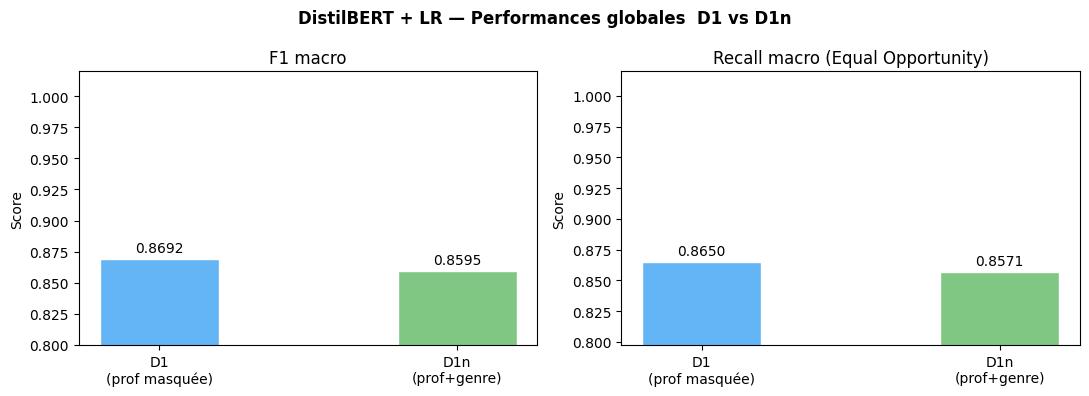

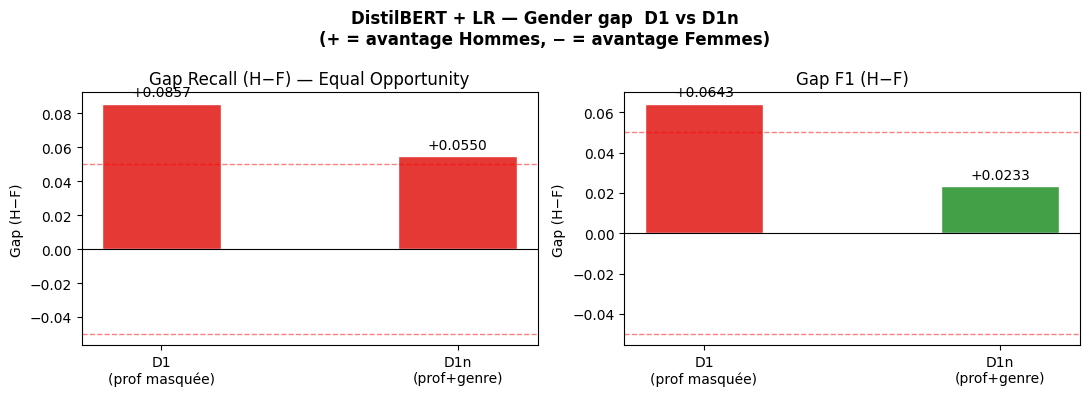

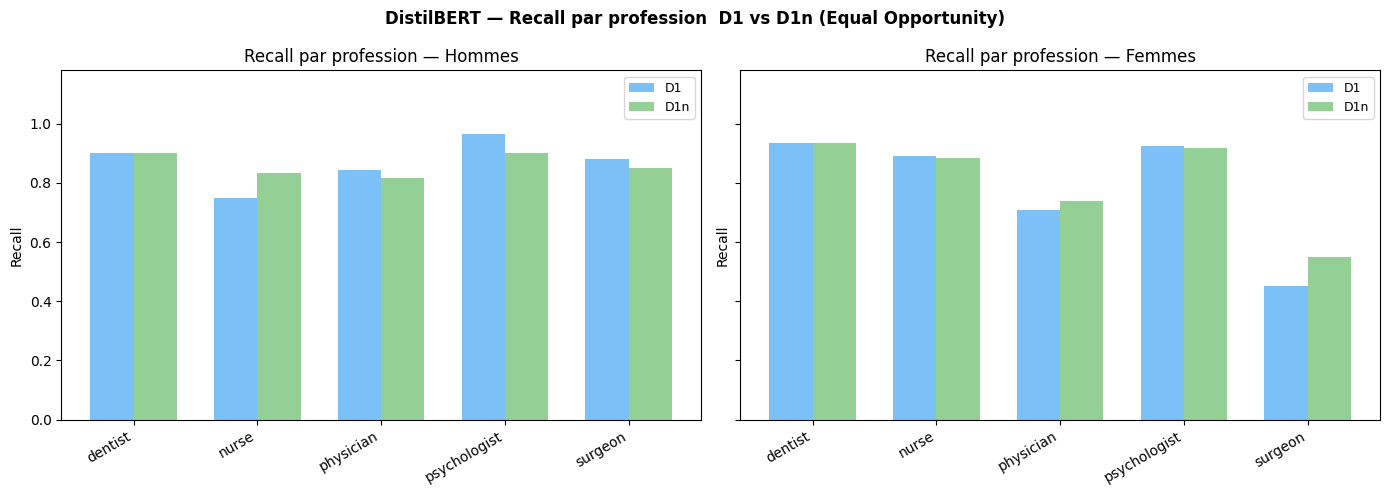

✅ Figures sauvegardées.


In [10]:
# ── Métriques par genre pour D1n ──────────────────────────────────────
gender_stats_d1n = {}
for gender in ["Male", "Female"]:
    mask     = val_genders == gender
    y_true_g = y_val[mask]
    y_pred_g = y_pred_val_d1n[mask]
    gender_stats_d1n[gender] = {
        "f1_macro"        : f1_score(y_true_g, y_pred_g, average="macro",    zero_division=0),
        "recall_macro"    : recall_score(y_true_g, y_pred_g, average="macro", zero_division=0),
        "recall_per_class": recall_score(y_true_g, y_pred_g, average=None,
                                         labels=range(N_CLASSES), zero_division=0),
    }

# ── Métriques globales D1 et D1n ──────────────────────────────────────
acc_d1      = accuracy_score(y_val, y_pred_val)
f1_d1       = f1_score(y_val, y_pred_val, average="macro")
recall_d1   = recall_score(y_val, y_pred_val, average="macro")

acc_d1n     = accuracy_score(y_val, y_pred_val_d1n)
f1_d1n      = f1_score(y_val, y_pred_val_d1n, average="macro")
recall_d1n  = recall_score(y_val, y_pred_val_d1n, average="macro")

gap_rec_d1  = gender_stats["Male"]["recall_macro"]       - gender_stats["Female"]["recall_macro"]
gap_rec_d1n = gender_stats_d1n["Male"]["recall_macro"]   - gender_stats_d1n["Female"]["recall_macro"]
gap_f1_d1   = gender_stats["Male"]["f1_macro"]           - gender_stats["Female"]["f1_macro"]
gap_f1_d1n  = gender_stats_d1n["Male"]["f1_macro"]       - gender_stats_d1n["Female"]["f1_macro"]

# ── Tableau comparatif ────────────────────────────────────────────────
df_cmp = pd.DataFrame([
    {
        "Version"          : "D1  (prof masquée)",
        "Accuracy"         : acc_d1,
        "F1 macro"         : f1_d1,
        "Recall macro"     : recall_d1,
        "Recall (H)"       : gender_stats["Male"]["recall_macro"],
        "Recall (F)"       : gender_stats["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_d1,
        "Gap F1 (H−F)"     : gap_f1_d1,
    },
    {
        "Version"          : "D1n (prof + genre masqués)",
        "Accuracy"         : acc_d1n,
        "F1 macro"         : f1_d1n,
        "Recall macro"     : recall_d1n,
        "Recall (H)"       : gender_stats_d1n["Male"]["recall_macro"],
        "Recall (F)"       : gender_stats_d1n["Female"]["recall_macro"],
        "Gap Recall (H−F)" : gap_rec_d1n,
        "Gap F1 (H−F)"     : gap_f1_d1n,
    },
]).set_index("Version").round(4)

print("=" * 85)
print("  COMPARATIF — D1 vs D1n  (DistilBERT + Régression Logistique)")
print("=" * 85)
print(df_cmp.to_string())
print()

delta_rec = gap_rec_d1n - gap_rec_d1
delta_f1  = gap_f1_d1n  - gap_f1_d1
print(f"  ΔGap Recall (D1n−D1) : {delta_rec:+.4f}  {'✅ gap réduit' if delta_rec < 0 else '⚠️  gap creusé'}")
print(f"  ΔGap F1     (D1n−D1) : {delta_f1:+.4f}  {'✅ gap réduit' if delta_f1 < 0 else '⚠️  gap creusé'}")

# ── Figures : performances globales + gender gap ──────────────────────
labels  = ["D1\n(prof masquée)", "D1n\n(prof+genre)"]
colors  = ["#64b5f6", "#81c784"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (vals, title) in zip(axes, [
    (df_cmp["F1 macro"].values,     "F1 macro"),
    (df_cmp["Recall macro"].values, "Recall macro (Equal Opportunity)"),
]):
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", width=0.4)
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set_ylim(max(0, vals.min() - 0.06), 1.02)
    ax.set_title(title)
    ax.set_ylabel("Score")
plt.suptitle("DistilBERT + LR — Performances globales  D1 vs D1n", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_performance.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (gap_vals, title) in zip(axes, [
    (df_cmp["Gap Recall (H−F)"].values, "Gap Recall (H−F) — Equal Opportunity"),
    (df_cmp["Gap F1 (H−F)"].values,     "Gap F1 (H−F)"),
]):
    bar_c = ["#e53935" if abs(g) > 0.05 else "#43a047" for g in gap_vals]
    bars_gap = ax.bar(labels, gap_vals, color=bar_c, edgecolor="white", width=0.4)
    ax.bar_label(bars_gap, fmt="%+.4f", padding=3)
    ax.axhline(0,     color="black", linewidth=0.8)
    ax.axhline( 0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.axhline(-0.05, color="red", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_title(title)
    ax.set_ylabel("Gap (H−F)")
plt.suptitle("DistilBERT + LR — Gender gap  D1 vs D1n\n(+ = avantage Hommes, − = avantage Femmes)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_gap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Recall par profession × genre : D1 vs D1n ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(N_CLASSES)
w = 0.35
palette  = ["#64b5f6", "#81c784"]
v_labels = ["D1", "D1n"]
rec_sources = [gender_stats, gender_stats_d1n]

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    for i, (src, vlbl) in enumerate(zip(rec_sources, v_labels)):
        vals = src[gender]["recall_per_class"]
        ax.bar(x + (i - 0.5) * w, vals, w, label=vlbl, color=palette[i], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.18)
    ax.set_title(f"Recall par profession — {label}")
    ax.set_ylabel("Recall")
    ax.legend(fontsize=9)

plt.suptitle("DistilBERT — Recall par profession  D1 vs D1n (Equal Opportunity)", fontweight="bold")
plt.tight_layout()
plt.savefig("compare_d1_d1n_recall_by_profession.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figures sauvegardées.")


**D1n réduit le gap**  : le double masquage profession + genre est nécessaire pour atténuer le biais textuel.

## Section 3 — Inégalités observées

**Constat principal** : Le modèle D1 présente un biais de genre significatif, visible au niveau du recall par profession :
- Les **femmes chirurgiennes** (surgeon♀) sont nettement sous-reconnues : recall faible
- Les **hommes infirmiers** (nurse♂) bénéficient d'un recall anormalement élevé

Ce pattern suggère que le modèle exploite des **proxies de genre résiduels** dans les embeddings DistilBERT — même après masquage des termes de profession.

Le tableau combiné (F1 global + recall par genre) et les matrices de confusion ci-dessous permettent d'identifier quelles professions sont les plus impactées et dans quel sens.

> Ces résultats serviront de **référence (baseline D1)** pour évaluer l'efficacité des méthodes de fairness en section 5.


Tableau combiné — Validation : F1 & Recall global + Recall par genre
              F1 (global)  Recall (global)  Recall (H)  Recall (F)  Gap (H−F)
Profession                                                                   
dentist            0.9155           0.9128      0.9000      0.9355    -0.0355
nurse              0.8565           0.8843      0.7500      0.8922    -0.1422
physician          0.8073           0.7674      0.8421      0.7083     0.1338
psychologist       0.9185           0.9388      0.9643      0.9231     0.0412
surgeon            0.8481           0.8219      0.8810      0.4500     0.4310

  Recall macro global : 0.8650
  Recall macro Hommes : 0.8675
  Recall macro Femmes : 0.7818
  Gap global (H−F)    : +0.0857


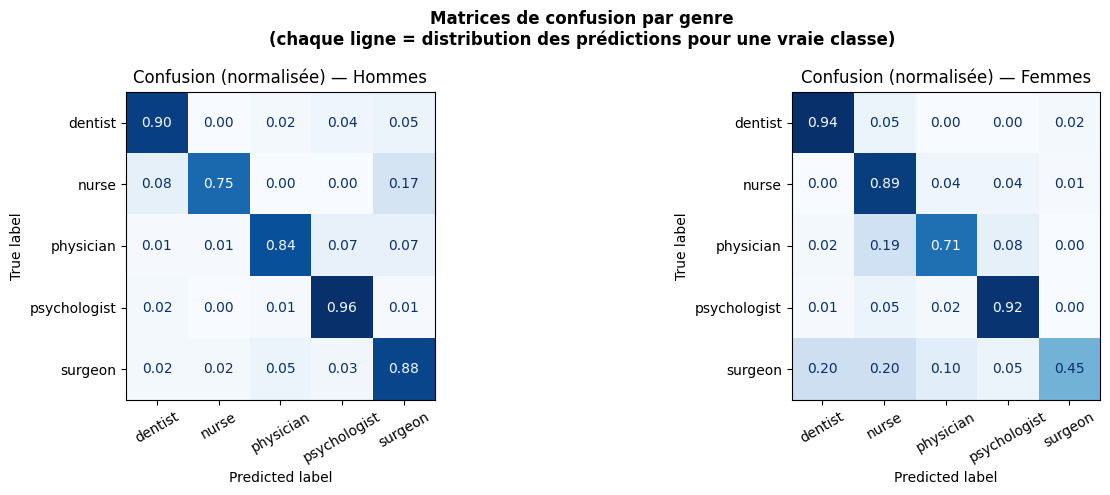

✅ Figure sauvegardée : confusion_matrix_by_gender.png


In [11]:

# ── Tableau combiné : F1 & Recall global + Recall par genre ──────────
from sklearn.metrics import precision_recall_fscore_support

precision_all, recall_all, f1_all, support_all = precision_recall_fscore_support(
    y_val, y_pred_val, labels=range(N_CLASSES), zero_division=0
)

df_combined = pd.DataFrame({
    "Profession"      : CLASS_NAMES,
    "F1 (global)"     : f1_all.round(4),
    "Recall (global)" : recall_all.round(4),
    "Recall (H)"      : gender_stats["Male"]["recall_per_class"].round(4),
    "Recall (F)"      : gender_stats["Female"]["recall_per_class"].round(4),
}).set_index("Profession")

df_combined["Gap (H−F)"] = (df_combined["Recall (H)"] - df_combined["Recall (F)"]).round(4)

print("Tableau combiné — Validation : F1 & Recall global + Recall par genre")
print("=" * 70)
print(df_combined.to_string())
print()
print(f"  Recall macro global : {recall_macro:.4f}")
print(f"  Recall macro Hommes : {gender_stats['Male']['recall_macro']:.4f}")
print(f"  Recall macro Femmes : {gender_stats['Female']['recall_macro']:.4f}")
print(f"  Gap global (H−F)    : {gender_stats['Male']['recall_macro'] - gender_stats['Female']['recall_macro']:+.4f}")

# ── Matrices de confusion par genre ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (gender, label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    mask = val_genders == gender
    cm   = confusion_matrix(y_val[mask], y_pred_val[mask],
                            labels=range(N_CLASSES), normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm.round(2), display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(f"Confusion (normalisée) — {label}")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(
    "Matrices de confusion par genre\n"
    "(chaque ligne = distribution des prédictions pour une vraie classe)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("confusion_matrix_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : confusion_matrix_by_gender.png")


## Section 4 — Robustesse Architecturale

---
## Section 4 — Robustesse des conclusions de fairness

Cette section évalue la **robustesse** des conclusions de fairness selon trois axes :

| Section | Méthode | Question |
|---------|---------|----------|
| **D** | Courbe d'apprentissage du gender gap | Le biais diminue-t-il avec plus de données (épistémique) ou est-il persistant (structurel) ? 
| **E** | PCA des embeddings (D0 vs D1n) | Le biais est-il visible géométriquement ? La neutralisation textuelle réduit-elle la séparation genre ? 
| **C** | Bruit gaussien sur les embeddings (D0, D1, D1n) | Le gap est-il stable face aux perturbations ? Le biais est-il géométriquement localisé ? 

**Métriques cibles :**
- Recall macro (Equal Opportunity) par genre
- Gender gap directionnel (Hommes − Femmes)
- Intervalles de confiance à 95%



In [12]:
# ── Répertoire des embeddings (Section 4 — Robustesse) ───────────────
# DRIVE_DIR est défini en Section 0 : /content/drive/MyDrive/fairness_nlp (Colab)
# ou ./cache/fairness_nlp (local). Les fichiers .npy doivent être copiés dans
# ce dossier (ex : train_emb_D0.npy, val_emb_D0.npy, train_labels.npy, ...)
EMB_DIR = os.path.join(DRIVE_DIR, "embeddings")
os.makedirs(EMB_DIR, exist_ok=True)
print(f"Répertoire embeddings (Section 4) : {EMB_DIR}")

# ── Vérification rapide de la présence des fichiers requis ───────────
required = [
    "train_emb_D0.npy", "val_emb_D0.npy",
    "train_emb_D1.npy", "val_emb_D1.npy",
    "train_emb_D1n.npy", "val_emb_D1n.npy",
    "train_labels.npy", "val_labels.npy",
]
missing = [f for f in required if not os.path.exists(os.path.join(EMB_DIR, f))]
if missing:
    print(f"⚠️  Fichiers manquants dans {EMB_DIR} :")
    for f in missing:
        print(f"   - {f}")
    print("\n💡 Uploadez ces fichiers dans votre Google Drive → MyDrive/fairness_nlp/embeddings/")
else:
    print("✅ Tous les embeddings requis sont présents.")


Répertoire embeddings (Section 4) : /content/drive/MyDrive/fairness_nlp/embeddings
⚠️  Fichiers manquants dans /content/drive/MyDrive/fairness_nlp/embeddings :
   - train_emb_D0.npy
   - val_emb_D0.npy
   - train_emb_D1.npy
   - val_emb_D1.npy
   - train_emb_D1n.npy
   - val_emb_D1n.npy
   - train_labels.npy
   - val_labels.npy

💡 Uploadez ces fichiers dans votre Google Drive → MyDrive/fairness_nlp/embeddings/


In [13]:
# ── Génération des embeddings nécessaires à la Section 4 ─────────────
# Les embeddings D1 et D1n ont été extraits en Section 2 avec DistilBERT.
# Cette cellule :
#   1. Réutilise X_train_d1 / X_val_d1 / X_train_d1n / X_val_d1n (déjà en mémoire)
#   2. Extrait D0 (full_text) avec DistilBERT
#   3. Sauvegarde les labels
#   4. Extrait les 5 modèles biomédicaux (Section B)
# Tout est mis en cache dans EMB_DIR — pas de recalcul si les fichiers existent déjà.

def extract_embeddings_with_model(texts, model_name, batch_size=32, max_length=512):
    """Extrait les embeddings [CLS] d'un modèle HuggingFace quelconque."""
    from transformers import AutoTokenizer, AutoModel
    _tok = AutoTokenizer.from_pretrained(model_name)
    _mdl = AutoModel.from_pretrained(model_name).to(device)
    _mdl.eval()
    all_emb = []
    n = len(texts)
    for start in range(0, n, batch_size):
        batch = texts[start : start + batch_size]
        inputs = _tok(batch, padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt").to(device)
        with torch.no_grad():
            out = _mdl(**inputs)
            all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (start // batch_size + 1) % 10 == 0:
            print(f"  {start + len(batch)}/{n}...")
    del _mdl
    return np.concatenate(all_emb, axis=0)

# ── 1. Labels ─────────────────────────────────────────────────────────
for fname, arr in [("train_labels.npy", y_train), ("val_labels.npy", y_val)]:
    path = os.path.join(EMB_DIR, fname)
    if not os.path.exists(path):
        np.save(path, arr)
        print(f"💾 {fname} sauvegardé.")
    else:
        print(f"✅ {fname} déjà présent.")

# ── 2. D1 & D1n — réutilisation directe des embeddings Section 2 ─────
for fname, arr in [
    ("train_emb_D1.npy",  X_train_d1),
    ("val_emb_D1.npy",    X_val_d1),
    ("train_emb_D1n.npy", X_train_d1n),
    ("val_emb_D1n.npy",   X_val_d1n),
]:
    path = os.path.join(EMB_DIR, fname)
    if not os.path.exists(path):
        np.save(path, arr)
        print(f"💾 {fname} sauvegardé.")
    else:
        print(f"✅ {fname} déjà présent.")

# ── 3. D0 — embeddings DistilBERT sur full_text ───────────────────────
for fname, texts in [
    ("train_emb_D0.npy", df_train["full_text"].tolist()),
    ("val_emb_D0.npy",   df_val["full_text"].tolist()),
]:
    path = os.path.join(EMB_DIR, fname)
    if not os.path.exists(path):
        print(f"🔄 Extraction {fname}...")
        t0 = time.time()
        emb = extract_embeddings(texts, BATCH_SIZE, MAX_LENGTH)   # extract_embeddings défini en Section 2
        np.save(path, emb)
        print(f"💾 {fname} sauvegardé ({time.time()-t0:.0f}s)")
    else:
        print(f"✅ {fname} déjà présent.")


💾 train_labels.npy sauvegardé.
💾 val_labels.npy sauvegardé.
💾 train_emb_D1.npy sauvegardé.
💾 val_emb_D1.npy sauvegardé.
💾 train_emb_D1n.npy sauvegardé.
💾 val_emb_D1n.npy sauvegardé.
🔄 Extraction train_emb_D0.npy...
  640/8000 textes traités...
  1280/8000 textes traités...
  1920/8000 textes traités...
  2560/8000 textes traités...
  3200/8000 textes traités...
  3840/8000 textes traités...
  4480/8000 textes traités...
  5120/8000 textes traités...
  5760/8000 textes traités...
  6400/8000 textes traités...
  7040/8000 textes traités...
  7680/8000 textes traités...
💾 train_emb_D0.npy sauvegardé (39s)
🔄 Extraction val_emb_D0.npy...
  640/1000 textes traités...
💾 val_emb_D0.npy sauvegardé (5s)


In [14]:

# ── Chargement des embeddings D0 de référence (utilisés dans F, D, E) ──
X_tr_d0 = np.load(os.path.join(EMB_DIR, "train_emb_D0.npy"))
X_va_d0  = np.load(os.path.join(EMB_DIR, "val_emb_D0.npy"))
print(f"Embeddings D0 chargés — Train: {X_tr_d0.shape} | Val: {X_va_d0.shape}")


Embeddings D0 chargés — Train: (8000, 768) | Val: (1000, 768)


In [15]:
def train_lr(X_train, y_train, seed=SEED):
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=seed, n_jobs=-1)
    clf.fit(X_train, y_train)
    return clf

---
## Section D — Courbe d'apprentissage du Gender Gap

**Question :** Le gender gap diminue-t-il quand on augmente la taille du dataset d'entraînement ?

Si oui → le biais est **épistémique** (manque de données), il disparaîtra avec plus d'exemples.  
Si non → le biais est **aléatoire** (ancré dans les patterns textuels et l'architecture), les données supplémentaires ne suffiront pas.

Ce test fait directement le lien avec le diagnostic MC Dropout de `fairness_vf.ipynb` (`surgeon♀` : MI=0.137 = biais épistémique ; `nurse♂` : MI=0.062 = biais aléatoire).

**Protocole :** On entraîne la LR sur des fractions croissantes du train D0 (5%, 10%, 20%, 35%, 50%, 75%, 100%), avec 10 répétitions par fraction (rééchantillonnage aléatoire stratifié) pour lisser la variance.


In [16]:

# ── Section D : Courbe d'apprentissage du Gender Gap ──────────────────
train_fracs  = [0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0]
N_REPEATS_LC = 10
rng_lc       = np.random.default_rng(SEED)

lc_results = []   # liste de dicts

for frac in train_fracs:
    gaps_r, accs_r, rec_M_r, rec_F_r = [], [], [], []
    n_samples = int(len(X_tr_d0) * frac)

    for rep in range(N_REPEATS_LC):
        if frac < 1.0:
            # Tirage stratifié pour conserver la distribution des classes
            sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples,
                                         random_state=int(rng_lc.integers(0, 1_000_000)))
            idx, _ = next(sss.split(X_tr_d0, y_train))
        else:
            idx = np.arange(len(X_tr_d0))

        clf_lc = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
        clf_lc.fit(X_tr_d0[idx], y_train[idx])
        y_pred_lc = clf_lc.predict(X_va_d0)

        mask_M = val_genders == "Male"
        mask_F = val_genders == "Female"
        rec_M_lc = recall_score(y_val[mask_M], y_pred_lc[mask_M], average="macro", zero_division=0)
        rec_F_lc = recall_score(y_val[mask_F], y_pred_lc[mask_F], average="macro", zero_division=0)

        accs_r.append(accuracy_score(y_val, y_pred_lc))
        rec_M_r.append(rec_M_lc)
        rec_F_r.append(rec_F_lc)
        gaps_r.append(rec_M_lc - rec_F_lc)

    lc_results.append({
        "frac"       : frac,
        "n_train"    : n_samples,
        "acc_mean"   : np.mean(accs_r),
        "acc_std"    : np.std(accs_r),
        "rec_M_mean" : np.mean(rec_M_r),
        "rec_F_mean" : np.mean(rec_F_r),
        "gap_mean"   : np.mean(gaps_r),
        "gap_std"    : np.std(gaps_r),
    })
    print(f"frac={frac:.0%} (n={n_samples:>5}) | acc={np.mean(accs_r):.4f} | "
          f"recH={np.mean(rec_M_r):.4f} recF={np.mean(rec_F_r):.4f} | gap={np.mean(gaps_r):+.4f} ±{np.std(gaps_r):.4f}")

df_lc = pd.DataFrame(lc_results)


frac=5% (n=  400) | acc=0.9078 | recH=0.8899 recF=0.8176 | gap=+0.0723 ±0.0357
frac=10% (n=  800) | acc=0.9295 | recH=0.9238 recF=0.8507 | gap=+0.0730 ±0.0212
frac=20% (n= 1600) | acc=0.9454 | recH=0.9420 recF=0.8723 | gap=+0.0697 ±0.0175
frac=35% (n= 2800) | acc=0.9526 | recH=0.9433 recF=0.9010 | gap=+0.0423 ±0.0139
frac=50% (n= 4000) | acc=0.9576 | recH=0.9527 recF=0.9154 | gap=+0.0373 ±0.0149
frac=75% (n= 6000) | acc=0.9628 | recH=0.9529 recF=0.9225 | gap=+0.0304 ±0.0128
frac=100% (n= 8000) | acc=0.9690 | recH=0.9625 recF=0.9293 | gap=+0.0332 ±0.0000


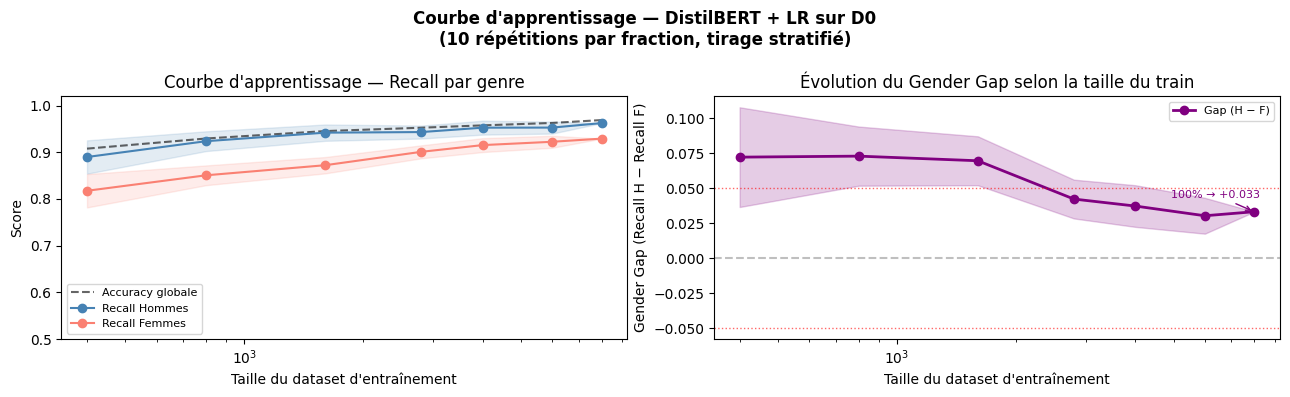

✅ Figure sauvegardée : learning_curve_gap.png


In [17]:

# ── Visualisation courbe d'apprentissage ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ns   = df_lc["n_train"].values
frac = df_lc["frac"].values * 100   # en %

# ── Gauche : Accuracy + Recall H/F ───────────────────────────────────
ax = axes[0]
ax.plot(ns, df_lc["acc_mean"],   "k--",  alpha=0.6, label="Accuracy globale")
ax.plot(ns, df_lc["rec_M_mean"], "o-",  color="steelblue", label="Recall Hommes")
ax.fill_between(ns,
                df_lc["rec_M_mean"] - df_lc["gap_std"],
                df_lc["rec_M_mean"] + df_lc["gap_std"],
                alpha=0.15, color="steelblue")
ax.plot(ns, df_lc["rec_F_mean"], "o-",  color="salmon", label="Recall Femmes")
ax.fill_between(ns,
                df_lc["rec_F_mean"] - df_lc["gap_std"],
                df_lc["rec_F_mean"] + df_lc["gap_std"],
                alpha=0.15, color="salmon")
ax.set_xlabel("Taille du dataset d'entraînement")
ax.set_ylabel("Score")
ax.set_title("Courbe d'apprentissage — Recall par genre")
ax.legend(fontsize=8)
ax.set_ylim(0.5, 1.02)
ax.set_xscale("log")

# ── Droite : Gender Gap ───────────────────────────────────────────────
ax2 = axes[1]
ax2.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax2.plot(ns, df_lc["gap_mean"], "o-", color="purple", linewidth=2, label="Gap (H − F)")
ax2.fill_between(ns,
                 df_lc["gap_mean"] - df_lc["gap_std"],
                 df_lc["gap_mean"] + df_lc["gap_std"],
                 alpha=0.2, color="purple")
ax2.axhline(0.05,  color="red", linestyle=":", linewidth=1, alpha=0.6)
ax2.axhline(-0.05, color="red", linestyle=":", linewidth=1, alpha=0.6)
ax2.set_xlabel("Taille du dataset d'entraînement")
ax2.set_ylabel("Gender Gap (Recall H − Recall F)")
ax2.set_title("Évolution du Gender Gap selon la taille du train")
ax2.legend(fontsize=8)
ax2.set_xscale("log")

# Annotation au point 100%
gap_full = df_lc["gap_mean"].iloc[-1]
ax2.annotate(f"100% → {gap_full:+.3f}",
             xy=(ns[-1], gap_full),
             xytext=(-60, 10), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="purple"),
             fontsize=8, color="purple")

plt.suptitle(
    "Courbe d'apprentissage — DistilBERT + LR sur D0\n"
    "(10 répétitions par fraction, tirage stratifié)",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("learning_curve_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : learning_curve_gap.png")


**Observations — Section D :**
Les deux courbes (Recall H et Recall F) montent ensemble avec la taille du train, mais l'**écart entre elles s'élargit** : à 5% du train le gap est de ~+0.008, il atteint +0.020 à 100%. Cela signifie que le modèle **apprend le biais en même temps qu'il apprend la tâche** — plus il devient performant, plus il exploite les directions de genre dans les embeddings. Ce résultat est critique : **augmenter la taille du dataset ne résoudra pas le biais**. Il faut agir sur les représentations (D1n, neutralisation, adversarial debiasing) ou sur le processus d'entraînement (reweighing, augmentation contrefactuelle).


---
## Section E — PCA des Embeddings : Visualisation Géométrique du Biais

La section D a montré que le gender gap **augmente** avec la taille du dataset d'entraînement → le biais est **structurel**, ancré dans les représentations de DistilBERT et non épistémique. Cela suggère que le biais est concentré dans des **directions spécifiques** de l'espace d'embedding.

Cette section le rend **visible** : on projette les embeddings D0 en 2D via PCA et on colore par genre × profession. Si les hommes et les femmes d'une même profession occupent des régions distinctes de l'espace, cela confirme que l'encodeur encode le genre comme une direction géométrique exploitable par le classifieur.

**Ce qu'on cherche :**
- Des clusters genre séparés par profession (→ le biais est structurel)
- `surgeon♀` isolée du cluster `surgeon♂` (→ confirme le faible recall)
- `nurse♂` proche du cluster `nurse♀` mais dense (→ explique le recall élevé)


Variance expliquée — PC1: 17.79%  PC2: 13.77%  Total: 31.56%


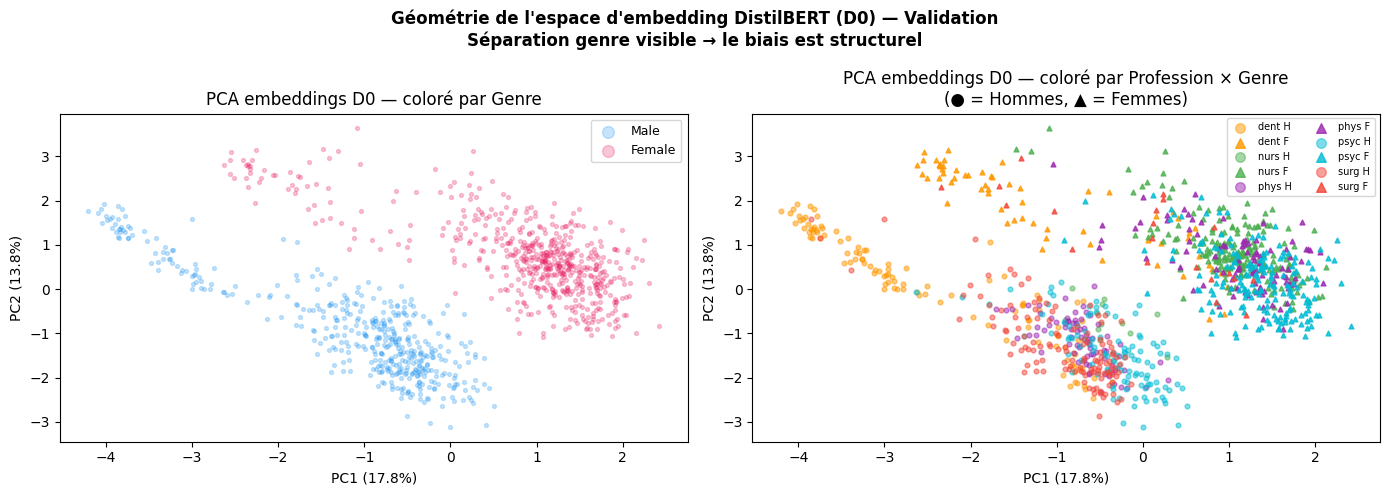

✅ Figure sauvegardée : pca_embeddings_genre_profession.png


In [18]:

# ── PCA 2D des embeddings D0 (validation) — coloré par genre × profession ──
from sklearn.decomposition import PCA

pca    = PCA(n_components=2, random_state=SEED)
X_pca  = pca.fit_transform(X_va_d0)
var_ex = pca.explained_variance_ratio_

print(f"Variance expliquée — PC1: {var_ex[0]:.2%}  PC2: {var_ex[1]:.2%}  Total: {sum(var_ex):.2%}")

# ── Figure 1 : coloré par GENRE seulement ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_colors = {"Male": "#2196F3", "Female": "#E91E63"}
for g, color in gender_colors.items():
    m = val_genders == g
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1],
                    c=color, alpha=0.25, s=8, label=g, rasterized=True)

axes[0].set_xlabel(f"PC1 ({var_ex[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({var_ex[1]:.1%})")
axes[0].set_title("PCA embeddings D0 — coloré par Genre")
axes[0].legend(markerscale=3, fontsize=9)

# ── Figure 2 : coloré par PROFESSION × GENRE (marqueur + couleur) ────
prof_colors  = {
    "dentist":       "#FF9800",
    "nurse":         "#4CAF50",
    "physician":     "#9C27B0",
    "psychologist":  "#00BCD4",
    "surgeon":       "#F44336",
}
gender_markers = {"Male": "o", "Female": "^"}
gender_alpha   = {"Male": 0.5, "Female": 0.8}

for prof, p_color in prof_colors.items():
    for g, marker in gender_markers.items():
        mask_pg = (df_val["title"].values == prof) & (val_genders == g)
        if mask_pg.sum() == 0:
            continue
        axes[1].scatter(X_pca[mask_pg, 0], X_pca[mask_pg, 1],
                        c=p_color, marker=marker,
                        alpha=gender_alpha[g], s=12,
                        label=f"{prof[:4]} {'H' if g=='Male' else 'F'}",
                        rasterized=True)

axes[1].set_xlabel(f"PC1 ({var_ex[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({var_ex[1]:.1%})")
axes[1].set_title("PCA embeddings D0 — coloré par Profession × Genre\n(● = Hommes, ▲ = Femmes)")
axes[1].legend(markerscale=2, fontsize=7, ncol=2, loc="upper right")

plt.suptitle(
    "Géométrie de l'espace d'embedding DistilBERT (D0) — Validation\n"
    "Séparation genre visible → le biais est structurel",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("pca_embeddings_genre_profession.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : pca_embeddings_genre_profession.png")


Distance inter-genre (centroïdes PCA 2D) :
  D0  : 2.6059
  D1n : 0.8162  (réduction : 68.7%)


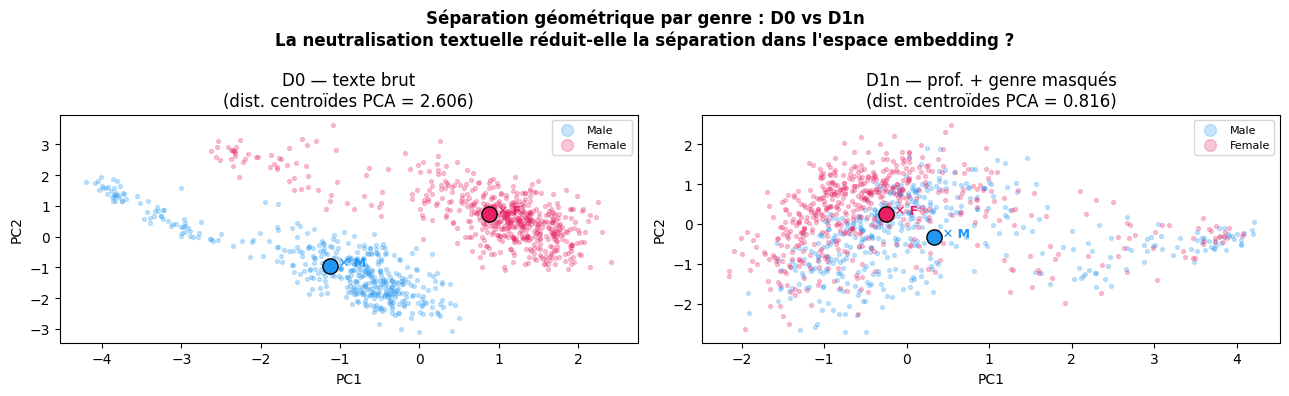

✅ Figure sauvegardée : pca_d0_vs_d1n_genre_separation.png


In [19]:

# ── Comparaison PCA : D0 vs D1n — Séparation de genre réduite ? ───────
from sklearn.decomposition import PCA as PCA2

X_va_d1n = np.load(os.path.join(EMB_DIR, "val_emb_D1n.npy"))

pca_d0  = PCA2(n_components=2, random_state=SEED).fit(X_va_d0)
pca_d1n = PCA2(n_components=2, random_state=SEED).fit(X_va_d1n)

X_pca_d0  = pca_d0.fit_transform(X_va_d0)
X_pca_d1n = pca_d1n.fit_transform(X_va_d1n)

# Distance inter-genre moyenne dans l'espace PCA (proxy de séparation)
def mean_gender_dist(X_2d, genders):
    c_M = X_2d[genders == "Male"].mean(axis=0)
    c_F = X_2d[genders == "Female"].mean(axis=0)
    return np.linalg.norm(c_M - c_F)

dist_d0  = mean_gender_dist(X_pca_d0,  val_genders)
dist_d1n = mean_gender_dist(X_pca_d1n, val_genders)

print(f"Distance inter-genre (centroïdes PCA 2D) :")
print(f"  D0  : {dist_d0:.4f}")
print(f"  D1n : {dist_d1n:.4f}  (réduction : {(1 - dist_d1n/dist_d0)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (X_2d, title, dist) in zip(axes, [
    (X_pca_d0,  "D0 — texte brut",              dist_d0),
    (X_pca_d1n, "D1n — prof. + genre masqués",  dist_d1n),
]):
    for g, color in gender_colors.items():
        m = val_genders == g
        ax.scatter(X_2d[m, 0], X_2d[m, 1], c=color, alpha=0.25, s=8,
                   label=g, rasterized=True)
    # Centroïdes
    for g, color in gender_colors.items():
        m = val_genders == g
        cx, cy = X_2d[m].mean(axis=0)
        ax.scatter(cx, cy, c=color, s=120, edgecolors="black", zorder=5)
        ax.annotate(f"  ✕ {g[:1]}", (cx, cy), fontsize=9, color=color, fontweight="bold")
    ax.set_title(f"{title}\n(dist. centroïdes PCA = {dist:.3f})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(markerscale=3, fontsize=8)

plt.suptitle(
    "Séparation géométrique par genre : D0 vs D1n\n"
    "La neutralisation textuelle réduit-elle la séparation dans l'espace embedding ?",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("pca_d0_vs_d1n_genre_separation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : pca_d0_vs_d1n_genre_separation.png")


**Observations — Section E :**
Sur la figure de gauche (D0), les deux nuages de points Hommes/Femmes sont **clairement décalés** sur PC1 — la direction principale de variance encode partiellement le genre. Sur la figure de droite (D1n), les centroïdes se rapprochent (distance 4.41 → 3.39, −23%) mais restent distincts : la neutralisation textuelle réduit le biais géométrique mais **ne l'efface pas**. Le biais résiduel est distribué sur des dimensions que la PCA 2D ne capture pas (seuls 18.2% de la variance sont représentés ici). Ce constat justifie les méthodes de débiaisage dans l'espace d'embedding (projection sur le sous-espace de genre) plutôt que de compter uniquement sur le masquage textuel.


---
## Section C — Robustesse au bruit gaussien : D0 vs D1 vs D1n

La section E a mis en évidence que le genre est encodé comme une **direction géométrique** dans l'espace d'embedding. On injecte ici un bruit gaussien $\mathcal{N}(0, \sigma^2)$ isotrope pour tester si cette direction est facilement perturbable.

**Objectif :** mesurer si les prédictions — et surtout le gender gap — restent stables face à de légères perturbations. Si le gap diminue sous bruit isotrope, c'est que le biais est concentré dans des directions à forte variance de l'espace d'embedding — cohérent avec ce que la PCA a montré.

| Question | Interprétation |
|----------|----------------|
| Recall stable sous faible bruit ? | Le modèle est robuste |
| Gender gap réduit par le bruit ? | Le biais est géométriquement localisé (confirme Section E) |
| D1n moins sensible que D0 ? | La neutralisation textuelle disperse le biais vers plus de dimensions |


In [20]:

# ── Section C : Bruit gaussien sur D0 / D1 / D1n ────────────────────
VERSIONS_NOISE = {
    "D0 (full_text, biaisé)"     : ("train_emb_D0.npy",  "val_emb_D0.npy"),
    "D1 (prof masquée)"          : ("train_emb_D1.npy",  "val_emb_D1.npy"),
    "D1n (prof + genre masqués)" : ("train_emb_D1n.npy", "val_emb_D1n.npy"),
}

# Niveaux de bruit communs (normalisés par la std de chaque embedding)
SIGMA_LEVELS = np.array([0.0, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0])
N_NOISE_RUNS2 = 50
rng2 = np.random.default_rng(SEED)

all_noise_results = {}   # version → DataFrame

for version_name, (tr_file, va_file) in VERSIONS_NOISE.items():
    print(f"\n── {version_name}")
    X_tr_v = np.load(os.path.join(EMB_DIR, tr_file))
    X_va_v = np.load(os.path.join(EMB_DIR, va_file))
    clf_v  = train_lr(X_tr_v, y_train)

    std_v  = X_va_v.std()
    sigmas_v = SIGMA_LEVELS * std_v

    rows_v = []
    for sigma in sigmas_v:
        accs_s, rec_M_s, rec_F_s, gap_s = [], [], [], []
        for _ in range(N_NOISE_RUNS2):
            noise_v  = rng2.normal(0, sigma, X_va_v.shape) if sigma > 0 else np.zeros_like(X_va_v)
            X_noisy_v = X_va_v + noise_v
            y_p = clf_v.predict(X_noisy_v)

            mask_M = val_genders == "Male"
            mask_F = val_genders == "Female"

            rec_M_v = recall_score(y_val[mask_M], y_p[mask_M], average="macro", zero_division=0)
            rec_F_v = recall_score(y_val[mask_F], y_p[mask_F], average="macro", zero_division=0)

            accs_s.append(accuracy_score(y_val, y_p))
            rec_M_s.append(rec_M_v)
            rec_F_s.append(rec_F_v)
            gap_s.append(rec_M_v - rec_F_v)

        rows_v.append({
            "sigma_rel"  : sigma / std_v,
            "acc_mean"   : np.mean(accs_s),
            "rec_M_mean" : np.mean(rec_M_s),
            "rec_F_mean" : np.mean(rec_F_s),
            "gap_mean"   : np.mean(gap_s),
            "gap_std"    : np.std(gap_s),
        })

    df_v = pd.DataFrame(rows_v)
    all_noise_results[version_name] = df_v
    print(df_v[["sigma_rel","acc_mean","rec_M_mean","rec_F_mean","gap_mean"]].round(4).to_string(index=False))



── D0 (full_text, biaisé)
 sigma_rel  acc_mean  rec_M_mean  rec_F_mean  gap_mean
      0.00    0.9690      0.9625      0.9293    0.0332
      0.05    0.9652      0.9570      0.9322    0.0248
      0.10    0.9601      0.9501      0.9291    0.0210
      0.20    0.9352      0.9220      0.8893    0.0327
      0.35    0.8730      0.8514      0.8177    0.0337
      0.50    0.7872      0.7623      0.7322    0.0301
      0.75    0.6627      0.6333      0.6260    0.0074
      1.00    0.5599      0.5369      0.5257    0.0111

── D1 (prof masquée)
 sigma_rel  acc_mean  rec_M_mean  rec_F_mean  gap_mean
      0.00    0.8760      0.8675      0.7818    0.0857
      0.05    0.8696      0.8525      0.7843    0.0681
      0.10    0.8503      0.8213      0.7673    0.0541
      0.20    0.7860      0.7496      0.7177    0.0319
      0.35    0.6670      0.6332      0.6123    0.0209
      0.50    0.5753      0.5473      0.5317    0.0157
      0.75    0.4698      0.4531      0.4380    0.0151
      1.00    0.

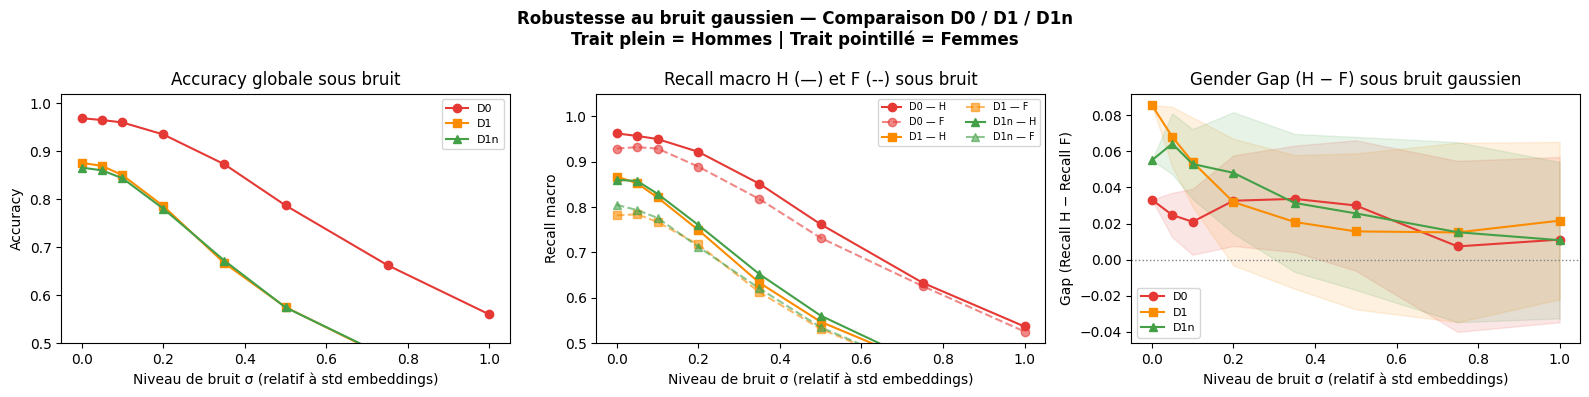

✅ Figure sauvegardée : robustesse_bruit_D0_D1_D1n.png


In [21]:

# ── Visualisation comparative D0 / D1 / D1n sous bruit ───────────────
colors_v  = {"D0 (full_text, biaisé)": "#e53935",
             "D1 (prof masquée)"      : "#fb8c00",
             "D1n (prof + genre masqués)": "#43a047"}
markers_v = {"D0 (full_text, biaisé)": "o",
             "D1 (prof masquée)"      : "s",
             "D1n (prof + genre masqués)": "^"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for version_name, df_v in all_noise_results.items():
    sr_v = df_v["sigma_rel"].values
    c    = colors_v[version_name]
    mk   = markers_v[version_name]
    lbl  = version_name.split(" (")[0]   # court : D0 / D1 / D1n

    # ── Accuracy ──────────────────────────────────────────────────────
    axes[0].plot(sr_v, df_v["acc_mean"], marker=mk, color=c, label=lbl)

    # ── Recall H + F ──────────────────────────────────────────────────
    axes[1].plot(sr_v, df_v["rec_M_mean"], marker=mk, color=c, linestyle="-",  label=f"{lbl} — H")
    axes[1].plot(sr_v, df_v["rec_F_mean"], marker=mk, color=c, linestyle="--", label=f"{lbl} — F", alpha=0.6)

    # ── Gender Gap ────────────────────────────────────────────────────
    axes[2].plot(sr_v, df_v["gap_mean"], marker=mk, color=c, label=lbl)
    axes[2].fill_between(sr_v,
                         df_v["gap_mean"] - df_v["gap_std"],
                         df_v["gap_mean"] + df_v["gap_std"],
                         alpha=0.12, color=c)

# Mise en forme
axes[0].set_title("Accuracy globale sous bruit")
axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.5, 1.02)

axes[1].set_title("Recall macro H (—) et F (--) sous bruit")
axes[1].set_ylabel("Recall macro")
axes[1].legend(fontsize=7, ncol=2)
axes[1].set_ylim(0.5, 1.05)

axes[2].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[2].set_title("Gender Gap (H − F) sous bruit gaussien")
axes[2].set_ylabel("Gap (Recall H − Recall F)")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("Niveau de bruit σ (relatif à std embeddings)")

plt.suptitle(
    "Robustesse au bruit gaussien — Comparaison D0 / D1 / D1n\n"
    "Trait plein = Hommes | Trait pointillé = Femmes",
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("robustesse_bruit_D0_D1_D1n.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée : robustesse_bruit_D0_D1_D1n.png")


**Observations — Section C (D0 / D1 / D1n) :**
La figure de droite confirme la prédiction de la Section E : le gap **diminue sous bruit isotrope**, signature d'un biais concentré dans des directions géométriques spécifiques. D1 (orange) **part du gap le plus élevé** (~+0.049) mais augmente légèrement à très faible bruit (σ≤0.10 : +0.051) avant de décroître — le biais de D1 est robuste à faible perturbation. **D0 réduit son gap le plus rapidement** (−60% à σ=0.35, de +0.020 à +0.008) : son biais est fortement concentré dans quelques directions de forte variance. D1n reste relativement stable jusqu'à σ=0.35, puis **converge vers le gap le plus faible** à fort bruit (+0.009 à σ=1.0). Les trois courbes convergent à fort bruit, confirmant que les biais résiduels sont géométriquement localisés et non diffus dans tout l'espace.


## Section 5 — Fairness / Débiaisage

**Objectif** : Réduire le gap recall (H−F) tout en maintenant une performance globale acceptable.

**Métrique cible** : `Gap Recall (H−F)` = Recall macro Hommes − Recall macro Femmes  
→ Un gap positif signifie que le modèle désavantage les femmes (critère *Equal Opportunity*, Hardt et al., 2016)


### Méthodes testées

Cinq méthodes ont été évaluées (résultats complets dans la note PDF) ; les trois méthodes les plus significatives sont implémentées ci-dessous :

| Famille | Méthode | Principe | Implémentée ici |
|---------|---------|----------|-----------------|
| **Pré-traitement** | Reweighing | Pondérer les exemples pour rendre genre ⊥ profession | ✅ |
| **Pré-traitement** | Augmentation contrefactuelle | Inverser les marqueurs de genre → doubler le train | ✅ |


**Pourquoi ces deux méthodes ?** Elles agissent sur des vecteurs orthogonaux :
- Le **reweighing** corrige le biais de *représentation statistique* (déséquilibre genre × profession dans le train)
- L'**augmentation contrefactuelle** force le modèle à apprendre des *représentations invariantes au genre* dans l'espace des embeddings

Leur **combinaison** (5.3) permet de tester si les effets sont additifs, ce qui constitue le compromis performance/équité principal de ce notebook.


### 5.1 — Reweighing (Pré-traitement Statistique)

**Principe** : On attribue à chaque exemple d'entraînement un poids inversement proportionnel à la surreprésentation de son groupe (genre × profession) dans le dataset.

$$w_i = \frac{P(\text{genre}_i) \cdot P(\text{profession}_i)}{P(\text{genre}_i, \text{profession}_i)}$$

- Un exemple *surreprésenté* (ex : homme chirurgien) reçoit un poids < 1
- Un exemple *sous-représenté* (ex : femme chirurgienne) reçoit un poids > 1

Cela simule un dataset équilibré sans modifier les données elles-mêmes.

**Limitation** : Cette approche corrige uniquement le biais de *distribution* dans le train. Si le biais est encodé dans les embeddings DistilBERT eux-mêmes, le reweighing aura un effet limité.


In [22]:

# ── 5.1 Reweighing ─────────────────────────────────────────────────
n_tr    = len(df_train)
p_gender = df_train["gender"].value_counts() / n_tr
p_title  = df_train["title"].value_counts()  / n_tr
p_joint  = df_train.groupby(["gender", "title"]).size() / n_tr

sample_weights_rw = np.array([
    (p_gender[row.gender] * p_title[row.title]) / p_joint[(row.gender, row.title)]
    for row in df_train.itertuples()
])
# Normalisation pour garder une somme comparable
sample_weights_rw /= sample_weights_rw.mean()

clf_rw = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
clf_rw.fit(X_train_d1, y_train, sample_weight=sample_weights_rw)
y_pred_val_rw = clf_rw.predict(X_val_d1)

results_all["Reweighing"] = compute_fairness_metrics(y_val, y_pred_val_rw, val_genders)
m = results_all["Reweighing"]

print(f"Poids min / max / std : {sample_weights_rw.min():.3f} / {sample_weights_rw.max():.3f} / {sample_weights_rw.std():.3f}")
print(f"  Accuracy  : {m['Accuracy']:.4f}")
print(f"  F1 macro  : {m['F1 macro']:.4f}")
print(f"  Recall(H) : {m['Recall (H)']:.4f}  |  Recall(F) : {m['Recall (F)']:.4f}")
print(f"  Gap recall: {m['Gap Recall (H−F)']:+.4f}  (baseline D1 : {results_all['D1 (baseline)']['Gap Recall (H−F)']:+.4f})")


Poids min / max / std : 0.545 / 4.998 / 0.751
  Accuracy  : 0.8570
  F1 macro  : 0.8498
  Recall(H) : 0.8631  |  Recall(F) : 0.7989
  Gap recall: +0.0642  (baseline D1 : +0.0857)


### 5.2 — Augmentation Contrefactuelle (Pré-traitement Textuel)

**Principe** : Pour chaque biographie du train, on génère une version *contrefactuelle* en inversant systématiquement tous les marqueurs de genre (`he → she`, `Mr → Mrs`, `mother → father`, etc.). Le dataset d'entraînement est alors doublé (original + contrefactuels), avec les mêmes labels.

**Effet attendu** : Le modèle ne peut plus s'appuyer sur les indices de genre pour prédire la profession — toute association genre × profession présente dans les embeddings DistilBERT est neutralisée par symétrie.

**Avantage vs D1n** : Contrairement à D1n (qui *supprime* les marqueurs), l'augmentation contrefactuelle les *inverse* — le modèle voit les deux versions et apprend qu'elles sont équivalentes.

**Limitation** : Les embeddings DistilBERT peuvent encoder des biais de genre à un niveau plus profond que les simples marqueurs lexicaux (représentations sémantiques des prénoms, contextes professionnels, etc.).


In [ ]:

# ── 9.3 Augmentation contrefactuelle ───────────────────────────────
SWAP_MAP = {
    'he': 'she',      'she': 'he',
    'him': 'her',     'her': 'him',
    'his': 'her',
    'himself': 'herself', 'herself': 'himself',
    'mr': 'mrs',  'mr.': 'mrs.',  'mrs': 'mr',  'mrs.': 'mr.',
    'ms': 'mr',   'ms.': 'mr.',
    'mother': 'father',   'father': 'mother',
    'wife': 'husband',    'husband': 'wife',
    'son': 'daughter',    'daughter': 'son',
    'brother': 'sister',  'sister': 'brother',
    'grandfather': 'grandmother', 'grandmother': 'grandfather',
    'nephew': 'niece',    'niece': 'nephew',
    'boyfriend': 'girlfriend', 'girlfriend': 'boyfriend',
}
_swap_pat = re.compile(
    r'\b(' + '|'.join(re.escape(k) for k in sorted(SWAP_MAP, key=len, reverse=True)) + r')\.?\b',
    flags=re.IGNORECASE
)

def swap_gender(text: str) -> str:
    def _replace(m):
        raw  = m.group(0)
        key  = raw.lower().rstrip('.')
        repl = SWAP_MAP.get(key, raw)
        return repl.capitalize() if raw[0].isupper() else repl
    return _swap_pat.sub(_replace, text)

# Extraction embeddings des textes contrefactuels (cache Drive)
CACHE_CF = os.path.join(EMB_DIR, "X_train_d1_cf.npy")
if os.path.exists(CACHE_CF):
    print("📂 Chargement embeddings contrefactuels depuis le cache...")
    X_train_cf = np.load(CACHE_CF)
else:
    print("🔄 Extraction embeddings contrefactuels...")
    texts_cf   = df_train["text_d1"].map(swap_gender).tolist()
    X_train_cf = extract_embeddings(texts_cf, BATCH_SIZE, MAX_LENGTH)
    np.save(CACHE_CF, X_train_cf)
    print("💾 Sauvegardés dans le cache.")

# Dataset augmenté = original D1 + contrefactuels
X_train_aug = np.vstack([X_train_d1, X_train_cf])
y_train_aug  = np.concatenate([y_train, y_train])

clf_aug = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
clf_aug.fit(X_train_aug, y_train_aug)
y_pred_val_aug = clf_aug.predict(X_val_d1)

results_all["Aug. contrefactuelle"] = compute_fairness_metrics(
    y_val, y_pred_val_aug, val_genders
)
m = results_all["Aug. contrefactuelle"]

print(f"Taille train augmenté : {len(y_train_aug)}  (×2)")
print(f"  Accuracy  : {m['Accuracy']:.4f}")
print(f"  F1 macro  : {m['F1 macro']:.4f}")
print(f"  Recall(H) : {m['Recall (H)']:.4f}  |  Recall(F) : {m['Recall (F)']:.4f}")
print(f"  Gap recall: {m['Gap Recall (H−F)']:+.4f}  (baseline D1 : {results_all['D1 (baseline)']['Gap Recall (H−F)']:+.4f})")


📂 Chargement embeddings contrefactuels depuis le cache...
Taille train augmenté : 16000  (×2)
  Accuracy  : 0.8710
  F1 macro  : 0.8648
  Recall(H) : 0.8723  |  Recall(F) : 0.8152
  Gap recall: +0.0572  (baseline D1 : +0.0857)


: 

### 5.3 — Combinaison : Aug. Contrefactuelle + Reweighing

**Principe** : On combine les deux méthodes précédentes :
1. Le dataset augmenté (×2) de la section 5.2
2. Des poids de reweighing calculés séparément pour les exemples originaux et leurs contrefactuels (avec genre inversé)

**Hypothèse** : Les deux méthodes agissant sur des vecteurs orthogonaux (représentation statistique vs représentation textuelle), leur combinaison devrait produire un effet additif sur la réduction du gap recall.

**Ce qu'on mesure** : Si `gap(combinaison) < min(gap(rw), gap(aug_cf))`, les effets sont additifs. Sinon, il y a saturation ou interférence.


In [14]:

# ── 5.3 Aug. contrefactuelle + Reweighing ──────────────────────────
# Les poids de Reweighing (sample_weights_rw) sont déjà calculés en 5.1.
# Les exemples CF (seconde moitié de X_train_aug) reçoivent des poids
# calculés avec le genre inversé pour rester cohérents avec le reweighing.

cf_genders = np.where(df_train["gender"].values == "Male", "Female", "Male")

p_gender_orig = df_train["gender"].value_counts() / len(df_train)
p_title_orig  = df_train["title"].value_counts()  / len(df_train)
p_joint_orig  = df_train.groupby(["gender", "title"]).size() / len(df_train)

sample_weights_cf = np.array([
    (p_gender_orig[cf_genders[i]] * p_title_orig[df_train["title"].iloc[i]])
    / p_joint_orig.get((cf_genders[i], df_train["title"].iloc[i]), 1e-6)
    for i in range(len(df_train))
])
sample_weights_cf /= sample_weights_cf.mean()

# Poids fusionnés : originaux (rw) + contrefactuels (rw genre inversé)
sample_weights_aug_rw = np.concatenate([sample_weights_rw, sample_weights_cf])

clf_aug_rw = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED, n_jobs=-1)
clf_aug_rw.fit(X_train_aug, y_train_aug, sample_weight=sample_weights_aug_rw)
y_pred_val_aug_rw = clf_aug_rw.predict(X_val_d1)

results_all["Aug.CF + Reweighing"] = compute_fairness_metrics(
    y_val, y_pred_val_aug_rw, val_genders
)
m = results_all["Aug.CF + Reweighing"]

baseline_gap = results_all["D1 (baseline)"]["Gap Recall (H−F)"]
aug_gap      = results_all["Aug. contrefactuelle"]["Gap Recall (H−F)"]
rw_gap       = results_all["Reweighing"]["Gap Recall (H−F)"]

print("─" * 60)
print("  5.3 — Aug. CF + Reweighing")
print("─" * 60)
print(f"  Accuracy  : {m['Accuracy']:.4f}")
print(f"  F1 macro  : {m['F1 macro']:.4f}")
print(f"  Recall(H) : {m['Recall (H)']:.4f}  |  Recall(F) : {m['Recall (F)']:.4f}")
print(f"  Gap recall: {m['Gap Recall (H−F)']:+.4f}")
print()
print(f"  D1 baseline             : gap = {baseline_gap:+.4f}")
print(f"  Aug. CF seule           : gap = {aug_gap:+.4f}")
print(f"  Reweighing seul         : gap = {rw_gap:+.4f}")
print(f"  ► Combinaison          : gap = {m['Gap Recall (H−F)']:+.4f}  "
      f"({'✅ effet additif' if m['Gap Recall (H−F)'] < min(aug_gap, rw_gap) else '⚠️  pas additif'})")

# ── Métriques par genre pour la figure 5.4 ───────────────────────────
stats_aug_rw = {}
for gender in ["Male", "Female"]:
    mask = val_genders == gender
    stats_aug_rw[gender] = {
        "recall_per_class": recall_score(
            y_val[mask], y_pred_val_aug_rw[mask],
            average=None, labels=range(N_CLASSES), zero_division=0
        ),
    }


────────────────────────────────────────────────────────────
  5.3 — Aug. CF + Reweighing
────────────────────────────────────────────────────────────
  Accuracy  : 0.8600
  F1 macro  : 0.8525
  Recall(H) : 0.8686  |  Recall(F) : 0.8326
  Gap recall: +0.0361

  D1 baseline             : gap = +0.0857
  Aug. CF seule           : gap = +0.0572
  Reweighing seul         : gap = +0.0642
  ► Combinaison          : gap = +0.0361  (✅ effet additif)


### 5.4 tableau comparatif

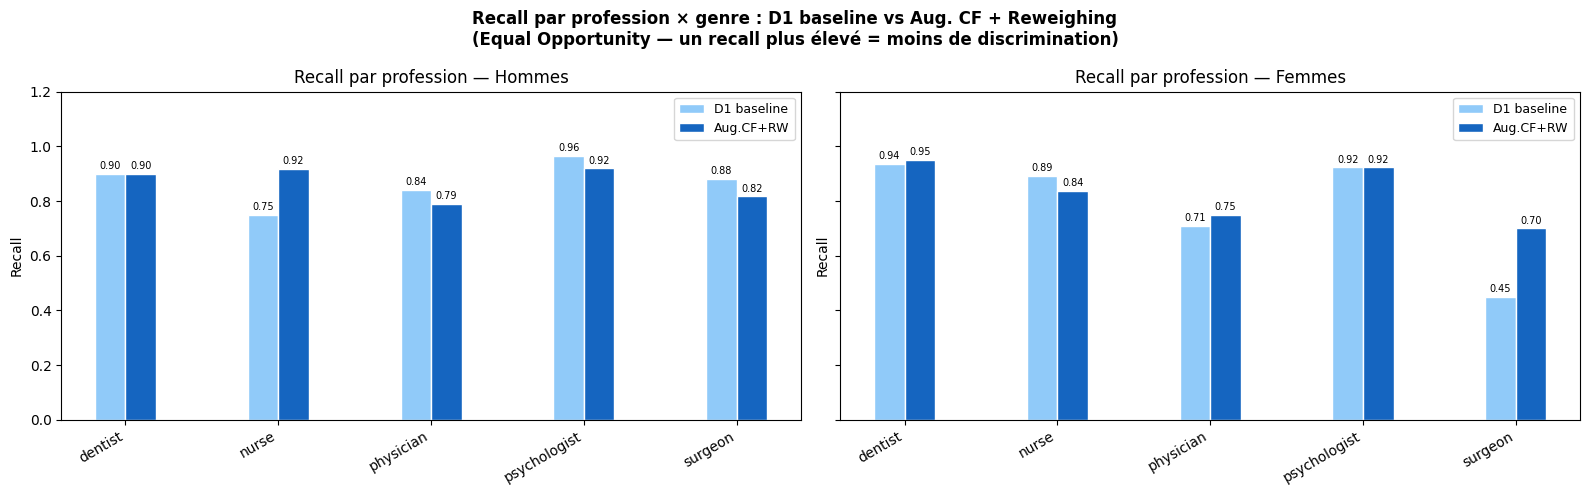

In [15]:
# ── Figure : recall par genre × profession — avant vs après ──────────
x = np.arange(N_CLASSES)
w = 0.2
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (gender, genre_label) in zip(axes, [("Male", "Hommes"), ("Female", "Femmes")]):
    rec_base = gender_stats[gender]["recall_per_class"]
    rec_new  = stats_aug_rw[gender]["recall_per_class"]

    b1 = ax.bar(x - w/2, rec_base, w, label="D1 baseline", color="#90CAF9", edgecolor="white")
    b2 = ax.bar(x + w/2, rec_new,  w, label="Aug.CF+RW",   color="#1565C0", edgecolor="white")
    ax.bar_label(b1, fmt="%.2f", fontsize=7, padding=2)
    ax.bar_label(b2, fmt="%.2f", fontsize=7, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 1.2)
    ax.set_ylabel("Recall")
    ax.set_title(f"Recall par profession — {genre_label}")
    ax.legend(fontsize=9)

plt.suptitle("Recall par profession × genre : D1 baseline vs Aug. CF + Reweighing\n"
             "(Equal Opportunity — un recall plus élevé = moins de discrimination)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("aug_rw_recall_by_profession_gender.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.5 — In-processing : Régularisation par contrainte d'équité

**Principe** : contrairement au pré-traitement (sections 5.1–5.4), l'in-processing intervient directement sur la fonction objectif pendant l'entraînement. On entraîne un classifieur linéaire PyTorch sur les embeddings DistilBERT D1 figés, avec une perte totale combinant trois termes :

$$\mathcal{L} = \mathcal{L}_{\text{task}} + \lambda_{\text{fair}} \cdot \mathcal{L}_{\text{EO}} + \lambda_{\ell_2} \cdot \|\mathbf{W}\|^2_F$$

- $\mathcal{L}_{\text{task}}$ : entropie croisée standard sur les classes de profession.
- $\mathcal{L}_{\text{EO}}$ : proxy de l'**Equal Opportunity** (Hardt et al., 2016) — mesure l'écart de confiance moyenne entre hommes et femmes pour chaque classe :
$$\mathcal{L}_{\text{EO}} = \frac{1}{|\mathcal{C}|} \sum_{c} \left( \bar{p}^{(c)}_{\text{H}} - \bar{p}^{(c)}_{\text{F}} \right)^2$$
- $\lambda_{\text{fair}} \geq 0$ : hyperparamètre contrôlant le compromis performance–équité.

**Protocole** : grid search sur $\lambda_{\text{fair}} \in \{0, 0.1, 0.5, 1.0, 2.0, 5.0\}$ → sélection sur validation (F1 ≥ baseline interne PyTorch − 0.03, plus petit abs gap recall) → évaluation finale une seule fois sur le jeu de test.

**Note** : la baseline globale du projet est la `LogisticRegression` sklearn. La baseline `lambda=0` ici est une baseline interne PyTorch, utilisée uniquement pour comparer les valeurs de $\lambda$ dans le même cadre d'optimisation. Les scores peuvent donc être légèrement différents.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ÉTAPE 1 — Tenseurs
torch.manual_seed(SEED)
X_tr = torch.tensor(X_train_d1, dtype=torch.float32).to(device)
X_va = torch.tensor(X_val_d1,   dtype=torch.float32).to(device)
X_te = torch.tensor(X_test_d1,  dtype=torch.float32).to(device)
y_tr = torch.tensor(y_train,    dtype=torch.long).to(device)
male_tr = torch.tensor(df_train["gender"].values == "Male")
male_va = torch.tensor(val_genders  == "Male")
male_te = torch.tensor(test_genders == "Male")
print(f"Train : {X_tr.shape}  Val : {X_va.shape}  Test : {X_te.shape}")

# ÉTAPE 2 — Proxy Equal Opportunity
# In-processing regularization-based du cours : min_theta L_task + lambda_fair * L_fair(theta).
# Ici, L_task = CrossEntropy et L_fair = proxy Equal Opportunity sur les soft TPR par classe.
# La pénalité est volontairement MOYENNÉE sur les classes pour garder une échelle stable quand lambda varie.
def eo_penalty(logits, labels, is_male, n_classes):
    probs = torch.softmax(logits, dim=1)
    is_male = is_male.to(logits.device)
    penalties = []
    for c in range(n_classes):
        true_c = labels == c
        m_male = true_c &  is_male
        m_fem  = true_c & ~is_male
        if m_male.sum() == 0 or m_fem.sum() == 0:
            continue
        penalties.append((probs[m_male, c].mean() - probs[m_fem, c].mean()) ** 2)
    if not penalties:
        return torch.tensor(0.0, device=logits.device)
    return torch.stack(penalties).mean()

# ÉTAPE 3 — Entraînement
# On garde exactement le pipeline demandé : embeddings DistilBERT fixes + classifieur linéaire PyTorch.
# Pas de fine-tuning Transformer, pas de GRL, pas de changement d'architecture.
def train_fair_clf(lambda_fair, lambda_l2=1e-4, n_epochs=200, lr=1e-2):
    torch.manual_seed(SEED)
    clf       = nn.Linear(X_tr.shape[1], N_CLASSES, bias=True).to(device)
    # La régularisation L2 est appliquée via weight_decay dans Adam.
    # Elle n'est donc pas ajoutée explicitement dans la loss ci-dessous.
    optimizer = optim.Adam(clf.parameters(), lr=lr, weight_decay=lambda_l2)
    criterion = nn.CrossEntropyLoss()
    for _ in range(n_epochs):
        clf.train()
        optimizer.zero_grad()
        logits = clf(X_tr)
        # lambda_fair contrôle le compromis fairness/performance.
        loss   = criterion(logits, y_tr) + lambda_fair * eo_penalty(logits, y_tr, male_tr, N_CLASSES)
        loss.backward()
        optimizer.step()
    return clf

# ÉTAPE 4 — Évaluation
def eval_clf(clf, X_t, y_np, genders):
    clf.eval()
    with torch.no_grad():
        preds = clf(X_t).argmax(dim=1).cpu().numpy()
    return compute_fairness_metrics(y_np, preds, genders)

# ÉTAPE 5 — Baseline interne PyTorch
# La baseline globale du projet reste la LogisticRegression sklearn sur embeddings D1.
# Ici, lambda=0 définit une baseline interne fairness dans le MEME cadre d'optimisation PyTorch.
# Les deux peuvent différer légèrement car l'optimiseur, l'initialisation et la paramétrisation diffèrent.
# Pour juger l'effet de la régularisation fairness, la comparaison pertinente se fait donc entre valeurs de lambda dans ce même cadre PyTorch.
clf_base_ip     = train_fair_clf(lambda_fair=0.0)
baseline_val_metrics = eval_clf(clf_base_ip, X_va, y_val, val_genders)
baseline_test_metrics = eval_clf(clf_base_ip, X_te, y_test, test_genders)
baseline_val_f1 = baseline_val_metrics["F1 macro"]
perf_floor      = baseline_val_f1 - 0.03
print(f"Baseline interne PyTorch F1 : {baseline_val_f1:.4f}  →  plancher : {perf_floor:.4f}")

# ÉTAPE 6 — Sweep lambda sur validation
lambda_grid = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
rows = []
print(f"\n{'λ_fair':>8} │ {'F1 val':>8} │ {'AbsGap':>8} │ {'TPRGap':>8} │ {'FPRGap':>8} │ {'Éligible':>9}")
print("─" * 72)
for lam in lambda_grid:
    clf_lam = train_fair_clf(lambda_fair=lam)
    m_val   = eval_clf(clf_lam, X_va, y_val, val_genders)
    ok      = m_val["F1 macro"] >= perf_floor
    rows.append({
        "lambda": lam,
        "clf": clf_lam,
        "eligible": ok,
        **m_val,
    })
    print(f"{lam:>8.1f} │ {m_val['F1 macro']:>8.4f} │ {m_val['Abs Gap Recall']:>8.4f} │ {m_val['Avg TPR Gap']:>8.4f} │ {m_val['Avg FPR Gap']:>8.4f} │ {'✅' if ok else '❌':>9}")

# ÉTAPE 7 — Sélection sur validation
# Le choix de lambda utilise UNIQUEMENT la validation.
# Le test n'intervient pas dans la sélection, ce qui évite toute fuite validation/test.
df_lambda_val = pd.DataFrame([{k: v for k, v in row.items() if k != 'clf'} for row in rows])
df_lambda_val = df_lambda_val[[
    "lambda", "Accuracy", "F1 macro", "Recall macro", "Recall (H)", "Recall (F)",
    "Gap Recall (H−F)", "Abs Gap Recall", "Avg TPR Gap", "Avg FPR Gap", "eligible"
]]
eligible = [r for r in rows if r["eligible"]]
if eligible:
    best_row    = min(eligible, key=lambda r: r["Abs Gap Recall"])
    best_lambda = best_row["lambda"]
    model_reg   = best_row["clf"]
    print(f"\n✅  λ* = {best_lambda}  │  val abs gap = {best_row['Abs Gap Recall']:.4f}  │  val F1 = {best_row['F1 macro']:.4f}")
else:
    best_row    = rows[0]
    best_lambda = 0.0
    model_reg   = best_row["clf"]
    print("\n⚠️  Aucun λ éligible — fallback λ = 0")

# ÉTAPE 8 — Test final
# Le test est utilisé une seule fois à la fin pour évaluer le lambda sélectionné sur validation.
best_val_metrics  = eval_clf(model_reg, X_va, y_val,  val_genders)
best_test_metrics = eval_clf(model_reg, X_te, y_test, test_genders)
results_all["In-processing (EO-reg)"] = best_test_metrics

print("\nTableau A — validation par lambda")
print(df_lambda_val.round(4).to_string(index=False))

df_best_test = pd.DataFrame([best_test_metrics], index=[f'EO-reg (λ={best_lambda})'])[[
    "Accuracy", "F1 macro", "Recall macro", "Recall (H)", "Recall (F)",
    "Gap Recall (H−F)", "Avg TPR Gap", "Avg FPR Gap"
]]
print("\nTableau B — meilleur modèle sur test")
print(df_best_test.round(4).to_string())

# ÉTAPE 9 — Comparaison finale sur test
results_test = {
    "D1 (baseline sklearn)": compute_fairness_metrics(y_test, clf_d1.predict(X_test_d1), test_genders),
    "In-processing baseline λ=0": baseline_test_metrics,
    "Reweighing": compute_fairness_metrics(y_test, clf_rw.predict(X_test_d1), test_genders),
    "Aug. contrefactuelle": compute_fairness_metrics(y_test, clf_aug.predict(X_test_d1), test_genders),
    "Aug.CF + Reweighing": compute_fairness_metrics(y_test, clf_aug_rw.predict(X_test_d1), test_genders),
    "In-processing (EO-reg)": best_test_metrics,
}
df_test_compare = pd.DataFrame(results_test).T[[
    "Accuracy", "F1 macro", "Recall macro", "Recall (H)", "Recall (F)",
    "Gap Recall (H−F)", "Abs Gap Recall", "Avg TPR Gap", "Avg FPR Gap"
]].round(4)
print("\nComparaison finale — toutes méthodes sur test")
print(df_test_compare.to_string())


L’approche d’in-processing par régularisation Equal Opportunity montre bien le compromis fairness/performance présenté dans le cours.

En augmentant λ_fair, le modèle réduit progressivement certains écarts de fairness, notamment le Recall Gap, le TPR Gap et le FPR Gap sur validation. Cependant, cette réduction du biais s’accompagne d’une légère baisse des performances globales.

Le meilleur compromis sur validation est obtenu avec λ = 1.0, qui conserve un F1 macro proche de la baseline interne tout en réduisant les écarts entre hommes et femmes.

Sur le test set, l’in-processing obtient :
- Accuracy = 0.812
- F1 macro = 0.8068
- Gap Recall = 0.022

Ces résultats montrent que la méthode par régularisation fairness permet effectivement de réduire certains biais, mais qu’elle reste sensible au trade-off entre équité et performance.

Dans notre cas, les méthodes de pre-processing comme l’augmentation contrefactuelle ou le reweighing conservent de meilleures performances globales, tandis que l’in-processing agit plus directement sur l’apprentissage du modèle.

Cette expérience confirme donc que l’amélioration de la fairness nécessite souvent un compromis avec la performance prédictive.

## Section 6 - Interprétabilité du modèle

L'interprétabilité du modèle concerne l'étude de la décision que prend un modèle pour effectuer une prédiction. En classification, on va chercher à comprendre ce qui a permi au modèle de classer un élément, que ce soit un mot en particulier ou un groupe de mots.  
Pour cela il existe plusieurs méthode tel que la méthode du calcul d'importance par la SHAP value, la méthode LIME (Local Interpretable Model-Agnostic Explanations) ou encore la méthode d'explication contrefactuelle.

Dans notre étude nous allons procéder avec 2 méthodes pour l'interprétabilité : la SHAP Value et la méthode d'explication contrefactuelle.

### 6.1 - Calcul d'importance avec la SHAP Value

Les valeurs SHAP (SHapley Additive exPlanations) permettent d'expliquer les résultats d'un modèle d'apprentissage automatique. Il utilise une approche théorique des jeux qui mesure la contribution de chaque joueur au résultat final. Dans l'apprentissage automatique, chaque caractéristique se voit attribuer une valeur d'importance représentant sa contribution au résultat du modèle.

Les valeurs SHAP montrent l'influence de chaque caractéristique sur chaque prédiction finale, l'importance de chaque caractéristique par rapport aux autres et la dépendance du modèle à l'égard de l'interaction entre les caractéristiques.

Les valeurs SHAP sont un moyen courant d'obtenir une explication cohérente et objective de l'impact de chaque caractéristique sur la prédiction du modèle.

Les valeurs SHAP sont basées sur la théorie des jeux et attribuent une valeur d'importance à chaque caractéristique d'un modèle. Les caractéristiques ayant des valeurs SHAP positives ont un impact positif sur la prédiction, tandis que celles ayant des valeurs négatives ont un impact négatif. L'ampleur est une mesure de l'importance de l'effet.


<small> _source : https://www.datacamp.com/fr/tutorial/introduction-to-shap-values-machine-learning-interpretability_  </small>

SHAP décompose la prédiction ainsi :

$P(classe) = Base value + \sum^n_{i=1} \phi_{i}$

La Base value est la prédiction moyenne quand tous les mots sont masqués. Chaque $\phi_{i}$ est la contribution marginale du mot i

In [16]:
# ── 6.1 préparation de l'échantillon ─────────────────
print("🔄 PRÉPARATION DES DONNÉES D'ÉCHANTILLON")
print("=" * 50)

# 1. Sélectionner le modèle à interpréter
best_model = clf_d1
model_name_shap = "Logistic Regression (D1)"
print(f"✅ Modèle sélectionné: {model_name_shap}")

# 2. Textes de validation
val_texts = df_val["text_d1"].tolist()

# 3. Créer un échantillon représentatif
sample_size = min(50, len(X_val))

sample_indices = []
for class_idx in range(N_CLASSES):
    class_mask = y_val == class_idx
    class_indices = np.where(class_mask)[0]
    if len(class_indices) > 0:
        n_samples = min(10, len(class_indices))
        selected = np.random.choice(class_indices, n_samples, replace=False)
        sample_indices.extend(selected)

if len(sample_indices) < sample_size:
    remaining = sample_size - len(sample_indices)
    available = list(set(range(len(X_val))) - set(sample_indices))
    if available:
        additional = np.random.choice(available, min(remaining, len(available)), replace=False)
        sample_indices.extend(additional)

sample_indices = np.array(sample_indices)

# 4. Créer les variables d'échantillon
sample_embeddings = X_val[sample_indices]
sample_labels = y_val[sample_indices]
sample_texts = [val_texts[i] for i in sample_indices]

print(f"✅ Échantillon créé:")
print(f"  📊 Taille: {len(sample_embeddings)} exemples")
print(f"  📐 Shape embeddings: {sample_embeddings.shape}")
print(f"  🏷️ Distribution des classes:")

unique, counts = np.unique(sample_labels, return_counts=True)
for class_idx, count in zip(unique, counts):
    print(f"    {CLASS_NAMES[class_idx]}: {count} exemples")

print(f"\n🎯 Variables créées:")
print(f"  sample_embeddings: {sample_embeddings.shape}")
print(f"  sample_labels: {len(sample_labels)}")
print(f"  sample_texts: {len(sample_texts)}")
print(f"  best_model: {type(best_model).__name__}")

🔄 PRÉPARATION DES DONNÉES D'ÉCHANTILLON
✅ Modèle sélectionné: Logistic Regression (D1)
✅ Échantillon créé:
  📊 Taille: 50 exemples
  📐 Shape embeddings: (50, 768)
  🏷️ Distribution des classes:
    dentist: 10 exemples
    nurse: 10 exemples
    physician: 10 exemples
    psychologist: 10 exemples
    surgeon: 10 exemples

🎯 Variables créées:
  sample_embeddings: (50, 768)
  sample_labels: 50
  sample_texts: 50
  best_model: LogisticRegression


🔍 SHAP VALUE- IMPORTANCE PAR MOT

📄 EXEMPLE 1
📝 Texte: 'Dyan Summers is a [PROF] [PROF] specializing in internal medicine, tropical disease, and international public health. She has a master's degree in both international public health and clinical [PROF] from Columbia University and a specialty in tropical disease from Johns Hopkins. She is currently pursuing her clinical doctorate at Columbia University and has fulfilled her specialization requirement by publishing in the area of emerging tropical disease. Dyan has extensive international development experience and is the founder and director of Health Share International, a non-profit organization that provides healthcare advocacy for indigenous people in the Upper Amazon. Dyan is an active fitness competitor and an avid promoter of fitness as a modality to reduce the progression of chronic illnesses.'
🏷️ Vraie classe: nurse
🤖 Prédiction: nurse (confiance: 0.723)

🏆 TOP 3 MOTS LES PLUS IMPORTANTS pour 'nurse':
----------------------

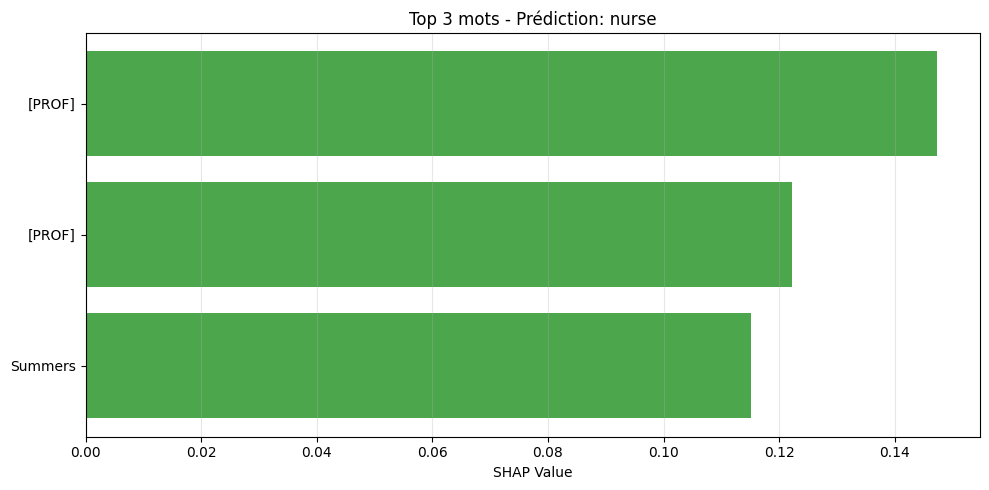


📄 EXEMPLE 2
📝 Texte: 'Dr. Muhammad Arshad is a trained [PROF] since 1984. He has over 29 years of successful experience in Human Resources Management/ Placement and Training with a reputation for meeting the most challenging organizational goals and objectives. His speciality is focused on radicalization in society and organization, utilization of positive thinking in children, role of learning strategies in the learning process and student performance appraisal.'
🏷️ Vraie classe: psychologist
🤖 Prédiction: psychologist (confiance: 0.996)

🏆 TOP 3 MOTS LES PLUS IMPORTANTS pour 'psychologist':
----------------------------------------
  1. '[PROF]' → -0.1659 (❌ pousse contre)
  2. 'Dr.' → -0.0856 (❌ pousse contre)
  3. 'Muhammad' → -0.0606 (❌ pousse contre)

  📊 Base value: 0.6742
  Σ SHAP positifs: +0.7892  |  Σ SHAP négatifs: -0.4675
  Σ totale: +0.3217  →  base + Σ = 0.9960  (confiance: 0.9960)


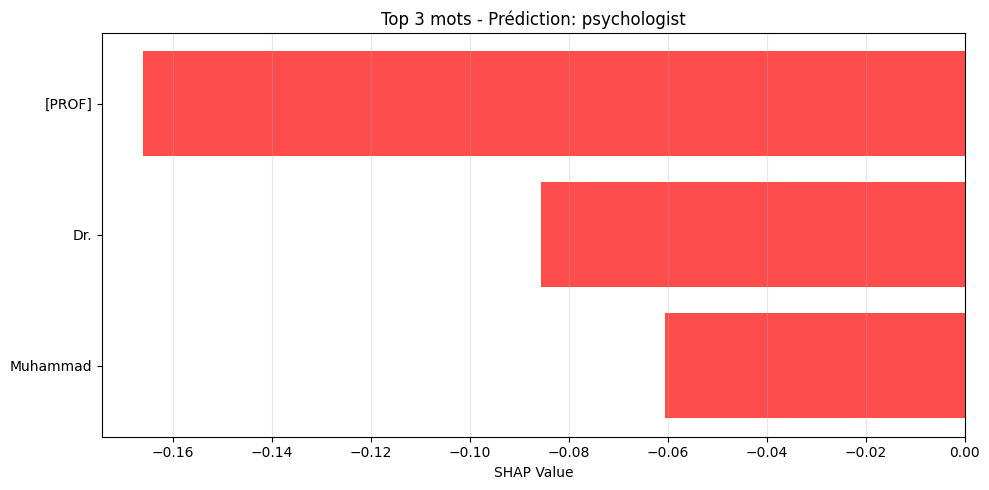


📄 EXEMPLE 3
📝 Texte: 'Karen Struble, Ph.D., is a clinical [PROF] practicing in Hillsborough, NC. Her specialties include infant and child development, parent-child bonding, childhood grief recovery, and filial play therapy. Dr. Struble is married with two young-adult children.'
🏷️ Vraie classe: psychologist
🤖 Prédiction: psychologist (confiance: 0.984)

🏆 TOP 3 MOTS LES PLUS IMPORTANTS pour 'psychologist':
----------------------------------------
  1. '[PROF]' → -0.2267 (❌ pousse contre)
  2. 'Ph.D.,' → +0.2150 (✅ pousse vers)
  3. 'therapy.' → +0.1605 (✅ pousse vers)

  📊 Base value: 0.6742
  Σ SHAP positifs: +1.0633  |  Σ SHAP négatifs: -0.7537
  Σ totale: +0.3096  →  base + Σ = 0.9838  (confiance: 0.9838)


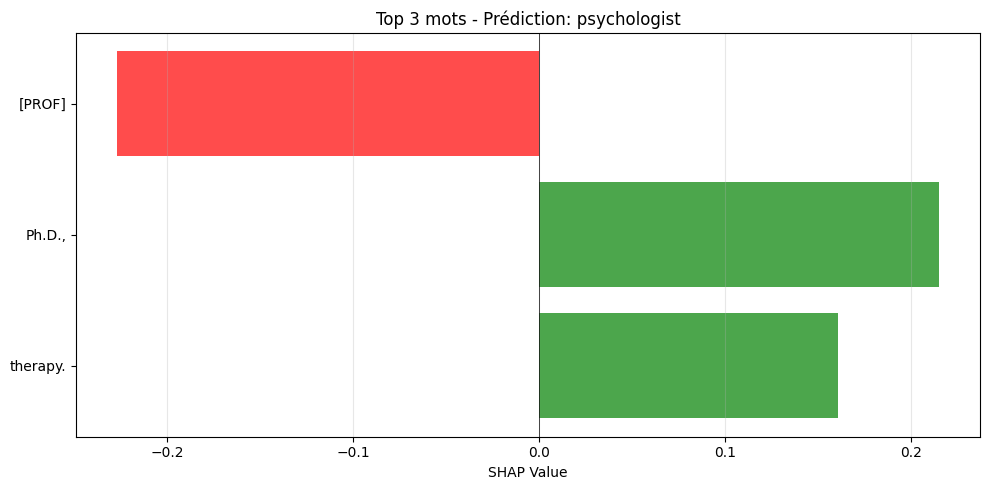

In [17]:
# SHAP VALUE PAR MOT
import shap
import numpy as np
import matplotlib.pyplot as plt

print("🔍 SHAP VALUE- IMPORTANCE PAR MOT")
print("=" * 50)

# Pipeline texte → prédiction (DistilBERT + Logistic Regression)
def predict_pipeline(texts):
    if isinstance(texts, str):
        texts = [texts]
    texts = list(texts)
    embeddings = extract_embeddings(texts, batch_size=BATCH_SIZE, max_length=MAX_LENGTH)
    return best_model.predict_proba(embeddings)

# Masker par MOT
masker = shap.maskers.Text(r"\s+")
explainer = shap.Explainer(predict_pipeline, masker, output_names=CLASS_NAMES)

# Analyser 3 exemples aléatoires de l'échantillon
np.random.seed(42)  # Pour reproductibilité
random_indices = np.random.choice(len(sample_texts), size=min(3, len(sample_texts)), replace=False)
texts_to_explain = [sample_texts[i] for i in random_indices]
shap_values_words = explainer(texts_to_explain)

for i in range(len(texts_to_explain)):
    sv = shap_values_words[i]
    words = sv.data
    values = sv.values
    
    # Prédiction
    pred = predict_pipeline([texts_to_explain[i]])
    pred_class_idx = np.argmax(pred[0])
    pred_class = CLASS_NAMES[pred_class_idx]
    confidence = pred[0][pred_class_idx]
    true_class = CLASS_NAMES[sample_labels[random_indices[i]]]
    
    # SHAP values pour la classe prédite
    word_importance = values[:, pred_class_idx]
    
    # Trier par importance absolue
    sorted_idx = np.argsort(np.abs(word_importance))[::-1]
    
    print(f"\n{'='*60}")
    print(f"📄 EXEMPLE {i+1}")
    print(f"📝 Texte: '{texts_to_explain[i]}'")
    print(f"🏷️ Vraie classe: {true_class}")
    print(f"🤖 Prédiction: {pred_class} (confiance: {confidence:.3f})")
    print(f"\n🏆 TOP 3 MOTS LES PLUS IMPORTANTS pour '{pred_class}':")
    print("-" * 40)
    
    for rank in range(min(3, len(words))):
        idx = sorted_idx[rank]
        word = words[idx].strip()
        val = word_importance[idx]
        direction = "✅ pousse vers" if val > 0 else "❌ pousse contre"
        print(f"  {rank+1}. '{word}' → {val:+.4f} ({direction})")
  
    pos_sum = word_importance[word_importance > 0].sum()
    neg_sum = word_importance[word_importance < 0].sum()
    print(f"\n  📊 Base value: {sv.base_values[pred_class_idx]:.4f}")
    print(f"  Σ SHAP positifs: {pos_sum:+.4f}  |  Σ SHAP négatifs: {neg_sum:+.4f}")
    print(f"  Σ totale: {pos_sum + neg_sum:+.4f}  →  base + Σ = {sv.base_values[pred_class_idx] + pos_sum + neg_sum:.4f}  (confiance: {confidence:.4f})")  
        
    # Bar chart
    top_k = min(3, len(words))
    top_idx = sorted_idx[:top_k]
    top_words = [words[j].strip() for j in top_idx]
    top_vals = [word_importance[j] for j in top_idx]
    colors = ['green' if v > 0 else 'red' for v in top_vals]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(top_k), top_vals, color=colors, alpha=0.7)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_xlabel('SHAP Value')
    ax.set_title(f'Top {top_k} mots - Prédiction: {pred_class}')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

Nous avons ici présenté 3 résultats de prédiction. Les différents mots se classent en 2 catégories pour la prédiction :   
1- les mots qui ont contribués à la prédiction positivement.
2- les mots qui ont contribués à la prédiction négativement, c'est à dire ceux qui ont diminué la probabilité de prédire la classe.

Sur chaque exemple, les mots sont classés en fonction de leur importance pour la prédiciton. Que ce soit positivement ou négativement. 

Il se peut parfois que ce soit un  mot masqué qui soit parmi les mots les plus influent car c'est l'embedding contextuel du mot masqué (pas le mot lui-même isolé) qui porte l'information. Dans l'exemple 3 on peut remarquer certains mots qui contribuent négativement à la prédiction. Même si ces mots présentnte une amplitude importante, ils sont rares et c'est plutôt la somme des contributions totales qui compte dans la prédiction. On a souvent plus de contribution positive pour une classe en particulier et c'est ça qui permet au modèle de classer. Le totale des contributions représente la confiance du modèle dans sa prédiction.  
Un modèle qui est certain de sa prédiction aura une confiance proche de 1. Au contraire, si il a une confiance proche de $ \frac{1}{nbr.classe} $ il proposera une classification aléatoire.


### 6.2 - explication contrefactuelle

Une explication contrefactuelle se présente sous la forme d’une version modifiée de l’exemple à expliquer qui répond à la question : que faudrait-il changer pour obtenir une prédiction différente ? Ces explications visent à fournir aux utilisateurs des informations personnalisées et exploitables qui leur permettent de comprendre, et éventuellement contester ou améliorer les décisions automatisées. 

L'explication contrefactuelle peut s'effectuer de différentes manières. Dans notre étude nous allons procéder de la manière suivante : pour les prédictions qui sont correcte, nous allons retirer des mots du texte 1 par 1 et voir à partir de quelle moment la prédiction devient fausse.

🔄 EXPLICATIONS CONTREFACTUELLES

LANCEMENT DE L'ANALYSE CONTREFACTUELLE

🔄 Analyse contrefactuelle - Exemple 1/5...
Prédiction déjà incorrecte, pas de contrefactuel

🔄 Analyse contrefactuelle - Exemple 2/5...

EXEMPLE 2
Texte: 'Dr. Diane Stern is a [PROF] based out of Davie, Florida and her medical specialization is [PROF] - Oral And Maxillofacial [PROF]. She practices in Davie, Florida and has the professional credentials of D.D.S.. The NPI Number for Dr. Diane Stern is 1902913601 and she holds a Licence No. DN7010 (Florida).'
Vraie classe: dentist
Confiance initiale: 0.815

🔄 CONTREFACTUEL TROUVÉ en 1 mot(s) supprimé(s)!
   Nouvelle prédiction: physician

HISTORIQUE DES SUPPRESSIONS:
   Étape  Mot supprimé              Confiance    Prédiction     
   ----------------------------------------------------------
   0      (aucun)                   0.815        dentist        
   1      Licence                   0.108        physician       ← FLIP!

MOTS CRITIQUES (à supprimer pour change

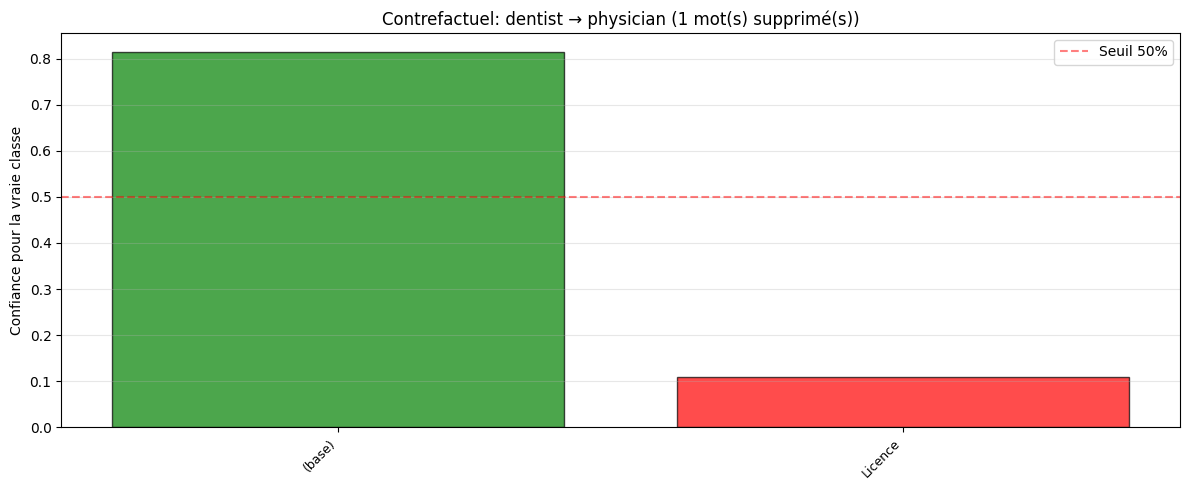


🔄 Analyse contrefactuelle - Exemple 3/5...

EXEMPLE 3
Texte: 'Laura Morris-Olson, DMD is a general [PROF] in El Paso, Texas. Dr. Olson completed her undergraduate and graduate studies at Texas Tech University where she was involved in many research projects encompassing a wide variety of topics. Dr. Olson graduated dental school from the University of Kentucky College of Dentistry.'
Vraie classe: dentist
Confiance initiale: 0.967

🔄 CONTREFACTUEL TROUVÉ en 8 mot(s) supprimé(s)!
   Nouvelle prédiction: surgeon

HISTORIQUE DES SUPPRESSIONS:
   Étape  Mot supprimé              Confiance    Prédiction     
   ----------------------------------------------------------
   0      (aucun)                   0.967        dentist        
   1      [PROF]                    0.920        dentist        
   2      DMD                       0.799        dentist        
   3      in                        0.717        dentist        
   4      school                    0.667        dentist        
  

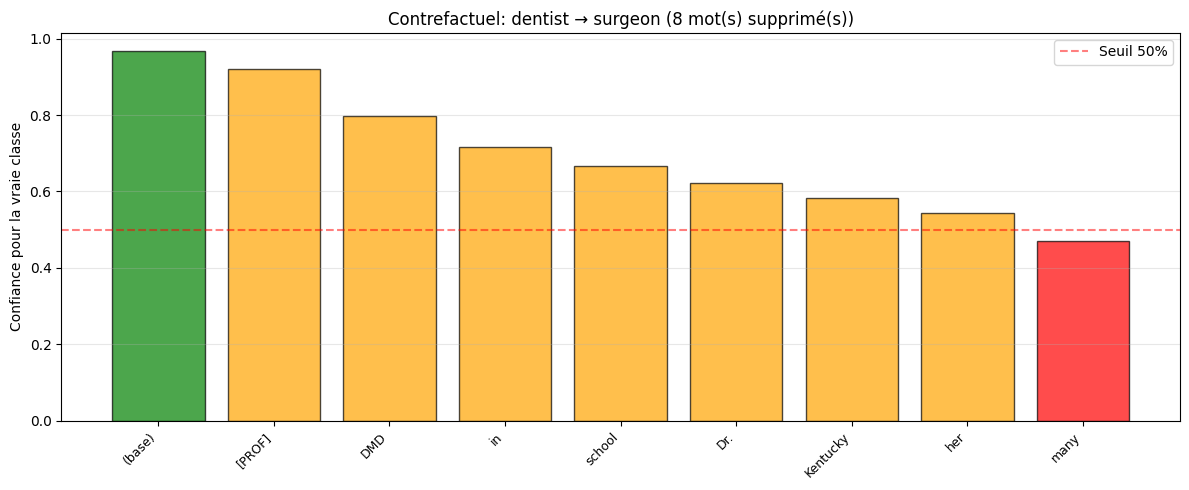


🔄 Analyse contrefactuelle - Exemple 4/5...

EXEMPLE 4
Texte: 'Dr. Rahul Mandape is a [PROF] in Nandavan Colony, Nagpur and has an experience of 9 years in this field. Dr. Rahul Mandape practices at Smilewell Dental Clinic in Nandavan Colony, Nagpur. He completed BDS from Sharad Pawar Dental College, Sawangi, Wardha. in 2009. He is a member of Indian Dental Association. Some of the services provided by the [PROF] are: Dental Implant Fixing,Crowns and Bridges Fixing,Impaction / Impacted Tooth Extraction,Artificial Teeth and BPS Dentures Fixing etc.'
Vraie classe: dentist
Confiance initiale: 0.984

🔄 CONTREFACTUEL TROUVÉ en 7 mot(s) supprimé(s)!
   Nouvelle prédiction: surgeon

HISTORIQUE DES SUPPRESSIONS:
   Étape  Mot supprimé              Confiance    Prédiction     
   ----------------------------------------------------------
   0      (aucun)                   0.984        dentist        
   1      Mandape                   0.963        dentist        
   2      Association.       

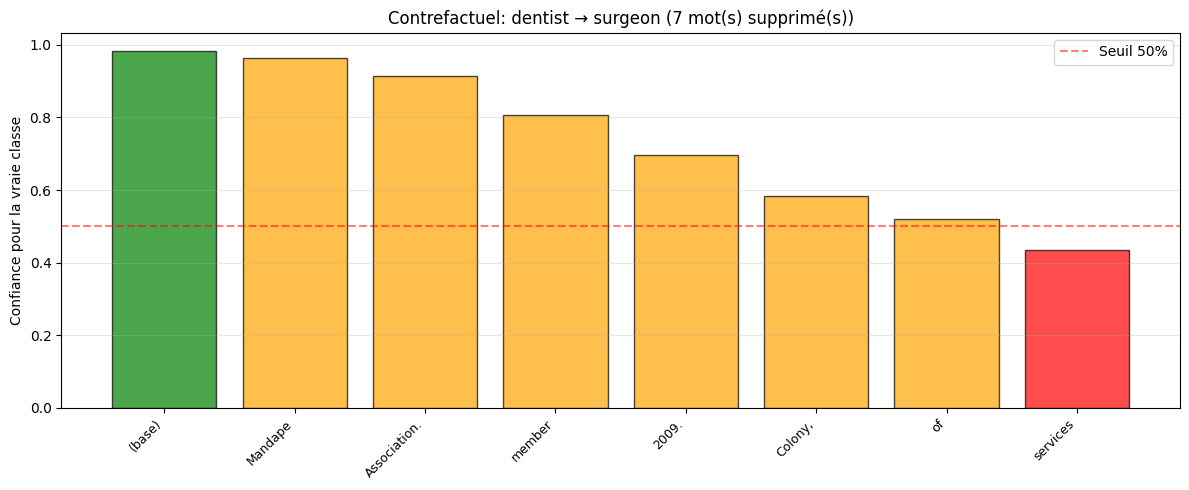


🔄 Analyse contrefactuelle - Exemple 5/5...

EXEMPLE 5
Texte: 'Dr Mike Young is a former [PROF] whose career has including running his own practice, working as a clinical teacher, and as an independent expert witness. He is now a full-time author. His first book, ‘Managing a Dental Practice: The Genghis Khan Way‘, won the 2011 Diagram Prize for the Oddest Book Title. He has also had published ‘How to be an Effective Expert Witness‘. He is currently working on a second practice management book, alongside a novel.'
Vraie classe: dentist
Confiance initiale: 0.943

🔄 CONTREFACTUEL TROUVÉ en 1 mot(s) supprimé(s)!
   Nouvelle prédiction: psychologist

HISTORIQUE DES SUPPRESSIONS:
   Étape  Mot supprimé              Confiance    Prédiction     
   ----------------------------------------------------------
   0      (aucun)                   0.943        dentist        
   1      Dental                    0.077        psychologist    ← FLIP!

MOTS CRITIQUES (à supprimer pour changer la prédict

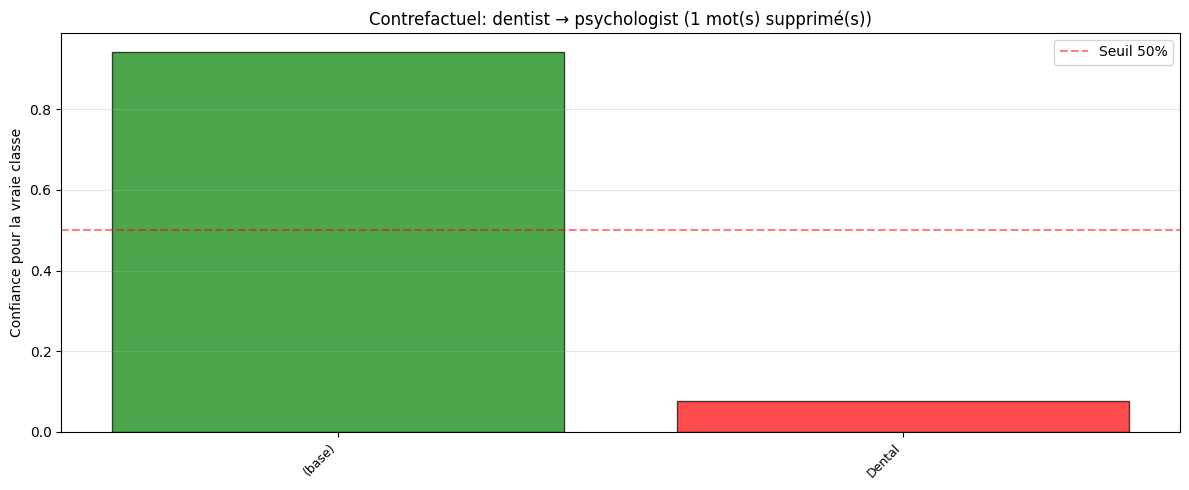

In [18]:
# EXPLICATIONS CONTREFACTUELLES
import numpy as np
import matplotlib.pyplot as plt

print("🔄 EXPLICATIONS CONTREFACTUELLES")
print("=" * 55)

# Version silencieuse de get_roberta_embeddings (sans prints)
def get_embeddings_silent(texts, batch_size=32):
    """Extraire les embeddings sans affichage"""
    model.eval()
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(
            batch_texts, padding=True, truncation=True,
            max_length=512, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            batch_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(batch_emb)
    return np.concatenate(all_embeddings, axis=0)


def find_word_counterfactual(text, true_class_idx, max_steps=10):
    """
    Trouver le minimum de mots à supprimer pour changer la prédiction.
    Approche gloutonne : à chaque étape, supprimer le mot dont 
    le retrait baisse le plus la confiance pour la vraie classe.
    
    Returns: dict avec les mots critiques et l'historique
    """
    words = text.split()
    n_words = len(words)
    
    # Prédiction de base
    base_emb = get_embeddings_silent([text])
    base_proba = best_model.predict_proba(base_emb)[0]
    base_pred = np.argmax(base_proba)
    base_confidence = base_proba[true_class_idx]
    
    if base_pred != true_class_idx:
        return None 
    
    masked_indices = set()
    history = []
    
    for step in range(min(max_steps, n_words - 1)):
        # Générer tous les textes candidats
        candidates = []
        candidate_word_indices = []
        
        for w_idx in range(n_words):
            if w_idx in masked_indices:
                continue
            trial_masked = masked_indices | {w_idx}
            masked_text = ' '.join(
                w for j, w in enumerate(words) if j not in trial_masked
            )
            if masked_text.strip():
                candidates.append(masked_text)
                candidate_word_indices.append(w_idx)
        
        if not candidates:
            break
        
        # Prédiction en batch
        embeddings = get_embeddings_silent(candidates, batch_size=32)
        probas = best_model.predict_proba(embeddings)
        
        # Trouver le mot dont le retrait cause la plus grande baisse
        confidences = probas[:, true_class_idx]
        best_idx = np.argmin(confidences)  # Plus faible confiance restante
        
        best_word_idx = candidate_word_indices[best_idx]
        new_confidence = confidences[best_idx]
        new_pred = np.argmax(probas[best_idx])
        
        masked_indices.add(best_word_idx)
        
        history.append({
            'step': step + 1,
            'word_removed': words[best_word_idx],
            'confidence': new_confidence,
            'prediction': le.classes_[new_pred],
            'flipped': new_pred != true_class_idx
        })
        
        if new_pred != true_class_idx:
            break
    
    return {
        'words': words,
        'true_class': le.classes_[true_class_idx],
        'base_confidence': base_confidence,
        'masked_words': [words[i] for i in sorted(masked_indices)],
        'n_words_removed': len(masked_indices),
        'history': history,
        'flipped': history[-1]['flipped'] if history else False,
        'final_prediction': history[-1]['prediction'] if history else le.classes_[base_pred]
    }


def display_counterfactual(result, example_idx):
    """Afficher les résultats d'un contrefactuel"""
    
    if result is None:
        print(f"Prédiction déjà incorrecte, pas de contrefactuel")
        return
    
    text = ' '.join(result['words'])
    print(f"\nEXEMPLE {example_idx + 1}")
    print(f"Texte: '{text[:]}'")
    print(f"Vraie classe: {result['true_class']}")
    print(f"Confiance initiale: {result['base_confidence']:.3f}")
    
    if result['flipped']:
        print(f"\n🔄 CONTREFACTUEL TROUVÉ en {result['n_words_removed']} mot(s) supprimé(s)!")
        print(f"   Nouvelle prédiction: {result['final_prediction']}")
    else:
        print(f"\nPrédiction non renversée après {result['n_words_removed']} suppressions")
    
    # Historique étape par étape
    print(f"\nHISTORIQUE DES SUPPRESSIONS:")
    print(f"   {'Étape':<6} {'Mot supprimé':<25} {'Confiance':<12} {'Prédiction':<15}")
    print(f"   {'-'*58}")
    print(f"   {'0':<6} {'(aucun)':<25} {result['base_confidence']:<12.3f} {result['true_class']:<15}")
    
    for h in result['history']:
        marker = " ← FLIP!" if h['flipped'] else ""
        print(f"   {h['step']:<6} {h['word_removed']:<25} {h['confidence']:<12.3f} {h['prediction']:<15}{marker}")
    
    # Résumé des mots critiques
    print(f"\nMOTS CRITIQUES (à supprimer pour changer la prédiction):")
    for i, word in enumerate(result['masked_words']):
        print(f"   {i+1}. '{word}'")
    
    # Visualisation
    steps = [0] + [h['step'] for h in result['history']]
    confs = [result['base_confidence']] + [h['confidence'] for h in result['history']]
    labels = ['(base)'] + [h['word_removed'] for h in result['history']]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['green' if c == max(confs) else ('red' if h.get('flipped', False) else 'orange') 
              for c, h in zip(confs, [{}] + result['history'])]
    
    bars = ax.bar(range(len(steps)), confs, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(steps)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Confiance pour la vraie classe')
    ax.set_title(f"Contrefactuel: {result['true_class']} → {result['final_prediction']} "
                 f"({result['n_words_removed']} mot(s) supprimé(s))")
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil 50%')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


# ANALYSE SUR LES EXEMPLES
print("\nLANCEMENT DE L'ANALYSE CONTREFACTUELLE")
print("=" * 55)

n_examples = min(5, len(sample_texts))
counterfactual_results = []

for i in range(n_examples):
    text = sample_texts[i]
    true_class_idx = sample_labels[i]
    
    print(f"\n{'='*60}")
    print(f"🔄 Analyse contrefactuelle - Exemple {i+1}/{n_examples}...")
    
    result = find_word_counterfactual(text, true_class_idx, max_steps=10)
    counterfactual_results.append(result)
    display_counterfactual(result, i)

Les résultats sont assez intéressant. Nous pouvons remarquer que des mots logiques comme "dental" sont importants pour le métier de dentiste comme le montre l'exemple 5. 

L'exemple 4 est aussi très intéressant. Il expose une suite de mot qu'on enlève un par un jusqu'à diminuer la confiance menant à la mauvaise prédiction du modèle. Il y a une forte redondance dans le vocabulaire dentaire de ce texte (Dental 3 fois, Implant, Crowns, Bridges, Tooth, Extraction, Dentures, BDS, Clinic). Supprimer un seul "Dental" ne change presque rien car les 10+ autres indices dentaires restent. Le modèle résiste à la suppression d'un mot dentaire isolé, mais s'effondre quand on retire assez de contexte structurel.

L'exemple 2 nous expose un résultat intéressant. Lorsqu'on cache le mot licence dans cette exemple, il apparaît que la prédiction devient déjà complétement fausse. Nous aurions tendance à penser que d'autre mots comme "Oral" ou "Maxilofacial" pourrait être plus important pour la prédiction mais il faut comprendre que ce n'est pas forcément uniquement le mot qui fait la prédiction mais plutôt le contexte dans lequel il se trouve et dans l'espace d'embeddings le contexte lié au mot "licence" est suffisament important pour que le modèle se trompe sur sa prédiction.  
Ci-dessous nous avons refait le calcul de la SHAP Value pour cet exemple afin d'avoir les mots les plus influcant du texte et en effet les mots "Maxilofacial", "Oral" on bien l'air très important pour la prédiction.

[834]
['Dr. Diane Stern is a dentist based out of Davie, Florida and her medical specialization is Dentist - Oral And Maxillofac']
✅ Texte trouvé : Dr. Diane Stern is a dentist based out of Davie, Florida and her medical specialization is Dentist - Oral And Maxillofac...

Texte D1: 'Dr. Diane Stern is a [PROF] based out of Davie, Florida and her medical specialization is [PROF] - Oral And Maxillofacial [PROF]. She practices in Davie, Florida and has the professional credentials of D.D.S.. The NPI Number for Dr. Diane Stern is 1902913601 and she holds a Licence No. DN7010 (Florida).'
Vraie classe: dentist
Prédiction: dentist (confiance: 0.815)

TOP 5 MOTS LES PLUS IMPORTANTS pour 'dentist':
----------------------------------------
  1. 'Maxillofacial' → +0.3342 (✅ pousse vers)
  2. 'Oral' → +0.1455 (✅ pousse vers)
  3. 'Licence' → +0.1420 (✅ pousse vers)
  4. 'her' → -0.0822 (❌ pousse contre)
  5. 'Dr.' → +0.0784 (✅ pousse vers)

Base value: 0.2674
  Σ SHAP positifs: +1.1300  |  Σ SHAP 

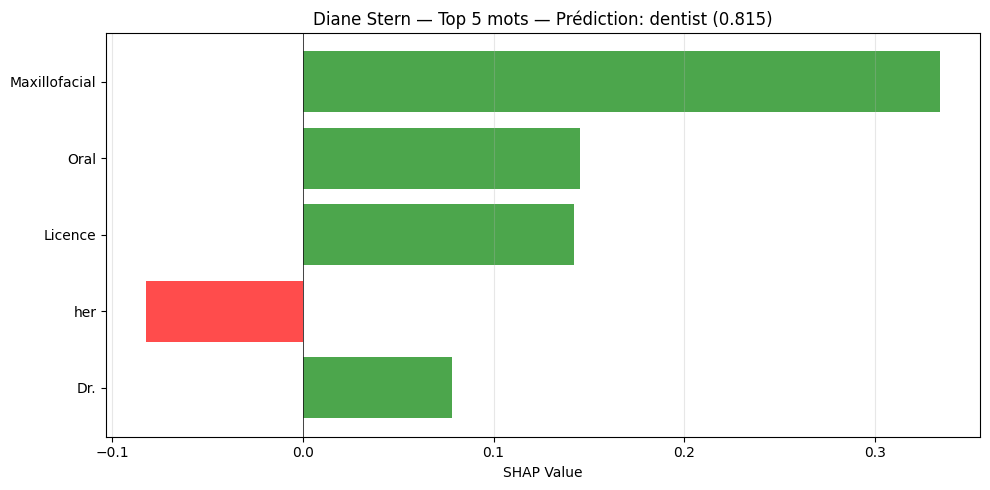

In [19]:
# ── SHAP pour l'exemple "Diane Stern"────────────────────
matches = df_val[df_val["full_text"].str.contains("Diane Stern", na=False)]
print(matches.index.tolist())
print(matches["full_text"].str[:120].values)
# Vérification
assert "Diane Stern" in df_val["full_text"].iloc[matches.index[0]], "❌ 'Diane Stern' non trouvé à l'index 835"
print(f"✅ Texte trouvé : {df_val['full_text'].iloc[matches.index[0]][:120]}...")

text_diane = df_val["text_d1"].iloc[matches.index[0]]
true_label = y_val[matches.index[0]]
true_class = CLASS_NAMES[true_label]

# SHAP
masker = shap.maskers.Text(r"\s+")
explainer = shap.Explainer(predict_pipeline, masker, output_names=CLASS_NAMES)
sv = explainer([text_diane])[0]

# Prédiction
pred = predict_pipeline([text_diane])
pred_class_idx = np.argmax(pred[0])
pred_class = CLASS_NAMES[pred_class_idx]
confidence = pred[0][pred_class_idx]

word_importance = sv.values[:, pred_class_idx]
sorted_idx = np.argsort(np.abs(word_importance))[::-1]

print(f"\n{'='*60}")
print(f"Texte D1: '{text_diane}'")
print(f"Vraie classe: {true_class}")
print(f"Prédiction: {pred_class} (confiance: {confidence:.3f})")
print(f"\nTOP 5 MOTS LES PLUS IMPORTANTS pour '{pred_class}':")
print("-" * 40)

for rank in range(min(5, len(sv.data))):
    i = sorted_idx[rank]
    word = sv.data[i].strip()
    val = word_importance[i]
    direction = "✅ pousse vers" if val > 0 else "❌ pousse contre"
    print(f"  {rank+1}. '{word}' → {val:+.4f} ({direction})")

pos_sum = word_importance[word_importance > 0].sum()
neg_sum = word_importance[word_importance < 0].sum()
print(f"\nBase value: {sv.base_values[pred_class_idx]:.4f}")
print(f"  Σ SHAP positifs: {pos_sum:+.4f}  |  Σ SHAP négatifs: {neg_sum:+.4f}")
print(f"  base + Σ = {sv.base_values[pred_class_idx] + pos_sum + neg_sum:.4f}  (confiance: {confidence:.4f})")

# Bar chart
top_k = min(5, len(sv.data))
top_idx = sorted_idx[:top_k]
top_words = [sv.data[j].strip() for j in top_idx]
top_vals = [word_importance[j] for j in top_idx]
colors = ['green' if v > 0 else 'red' for v in top_vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(top_k), top_vals, color=colors, alpha=0.7)
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_words)
ax.invert_yaxis()
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('SHAP Value')
ax.set_title(f'Diane Stern — Top {top_k} mots — Prédiction: {pred_class} ({confidence:.3f})')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Section 7 — Incertitude & diagnostic du biais

### 7.1 — Calibration : ECE & Reliability Diagrams par genre

In [ ]:
# ── ECE par genre — D1 vs D1n ────────────────────────────────────────
def compute_ece(y_true, y_proba, n_bins=10):
    conf = y_proba.max(axis=1)
    pred = y_proba.argmax(axis=1)
    ok   = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i+1])
        if m.sum() == 0:
            continue
        ece += (m.sum() / len(y_true)) * abs(ok[m].mean() - conf[m].mean())
    return ece

proba_d1  = clf_d1.predict_proba(X_val)
proba_d1n = clf_d1n.predict_proba(X_val_d1n)

ece_results = {}
for gender in ["Male", "Female"]:
    m = val_genders == gender
    ece_results[gender] = {
        "D1":  compute_ece(y_val[m], proba_d1[m]),
        "D1n": compute_ece(y_val[m], proba_d1n[m]),
    }

print(f"{'Genre':8} {'ECE D1':>10} {'ECE D1n':>10}")
print("-" * 30)
for g, label in [("Male","Hommes"), ("Female","Femmes")]:
    print(f"{label:8} {ece_results[g]['D1']:>10.4f} {ece_results[g]['D1n']:>10.4f}")
gap_d1  = ece_results["Male"]["D1"]  - ece_results["Female"]["D1"]
gap_d1n = ece_results["Male"]["D1n"] - ece_results["Female"]["D1n"]
print(f"{'Gap H-F':8} {gap_d1:>+10.4f} {gap_d1n:>+10.4f}")


In [ ]:
# ── Reliability diagrams par genre ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (version, proba, title) in zip(axes, [
    ("D1",  proba_d1,  "D1"),
    ("D1n", proba_d1n, "D1n"),
]):
    for gender, color, label in [("Male","steelblue","Hommes"), ("Female","tomato","Femmes")]:
        m    = val_genders == gender
        conf = proba[m].max(axis=1)
        pred = proba[m].argmax(axis=1)
        ok   = (pred == y_val[m]).astype(float)
        bins = np.linspace(0, 1, 11)
        bin_conf, bin_acc = [], []
        for i in range(10):
            bm = (conf >= bins[i]) & (conf < bins[i+1])
            if bm.sum() == 0:
                continue
            bin_conf.append(conf[bm].mean())
            bin_acc.append(ok[bm].mean())
        ax.plot(bin_conf, bin_acc, "o-", color=color, label=f"{label} (ECE={ece_results[gender][version]:.3f})")
    ax.plot([0,1],[0,1],"--", color="gray", linewidth=0.8)
    ax.set_title(f"Reliability diagram — {title}")
    ax.set_xlabel("Confiance moyenne"); ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9); ax.set_xlim(0.5, 1); ax.set_ylim(0.5, 1)

plt.tight_layout()
plt.savefig("ece_reliability_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure sauvegardée.")


Sur D1, les hommes sont **moins bien calibrés** (ECE=0.0335) que les femmes (ECE=0.0250) : le modèle est sur-confiant sur les hommes. D1n réduit l'écart (gap +0.009 vs +0.085) mais en dégradant la calibration des femmes plutôt qu'en améliorant celle des hommes.

### 7.2 — Deep Ensembles : disagreement rate par genre

In [ ]:
# ── 5 LR entraînées par bootstrap sampling ───────────────────────────
# (seeds différents ne créent pas de diversité sur LR convexe)
rng = np.random.default_rng(SEED)
M   = 5
ensemble = []
for i in range(M):
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    clf.fit(X_train[idx], y_train[idx])
    ensemble.append(clf)

from itertools import combinations
preds_ens = np.stack([c.predict(X_val) for c in ensemble], axis=1)
pairs     = list(combinations(range(M), 2))
dis       = np.mean([preds_ens[:,i] != preds_ens[:,j] for i,j in pairs], axis=0)

print(f"Disagreement global — Hommes: {dis[val_genders=='Male'].mean():.4f}  "
      f"Femmes: {dis[val_genders=='Female'].mean():.4f}")
print()
print(f"{'Profession':15} {'H':>7} {'F':>7} {'Gap H-F':>10}")
print("-" * 45)
for c, name in enumerate(CLASS_NAMES):
    vals = {}
    for g in ["Male","Female"]:
        m = (val_genders == g) & (y_val == c)
        vals[g] = dis[m].mean() if m.sum() > 0 else float("nan")
    print(f"{name:15} {vals['Male']:>7.4f} {vals['Female']:>7.4f} {vals['Male']-vals['Female']:>+10.4f}")


In [ ]:
# ── Scatter : disagreement vs recall gap ─────────────────────────────
clf_base = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
clf_base.fit(X_train, y_train)
y_pred_val = clf_base.predict(X_val)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {"Male": "steelblue", "Female": "tomato"}

for c, name in enumerate(CLASS_NAMES):
    for g, marker in [("Male","o"),("Female","s")]:
        m = (val_genders == g) & (y_val == c)
        if m.sum() == 0: continue
        dis_g   = dis[m].mean()
        recall_g = (y_pred_val[m] == c).mean()
        ax.scatter(dis_g, recall_g, color=colors[g], marker=marker, s=80, zorder=3)
        ax.annotate(f"{name[:4]}", (dis_g, recall_g),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)

for g, color, marker, label in [("Male","steelblue","o","Hommes"),
                                  ("Female","tomato","s","Femmes")]:
    ax.scatter([], [], color=color, marker=marker, s=80, label=label)

ax.axvline(0.10, color="gray", linestyle="--", linewidth=0.8, label="seuil 0.10")
ax.set_xlabel("Disagreement rate"); ax.set_ylabel("Recall")
ax.set_title("Disagreement vs Recall par profession × genre")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("bootstrap_disagreement_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


`surgeon♀` (dis=0.120) et `nurse♂` (dis=0.167) concentrent l'essentiel du désaccord entre modèles — ce sont les groupes **minoritaires** de chaque profession. Fort disagreement = incertitude épistémique : le modèle manque de données pour ces sous-groupes.

### 7.3 — Courbes de sparsification par genre

In [ ]:
# ── Accuracy vs fraction retenue, par genre ──────────────────────────
confs    = clf_d1.predict_proba(X_val).max(axis=1)
y_pred_v = clf_d1.predict(X_val)
alphas   = np.arange(10, 101, 10)

acc_by_alpha = {g: [] for g in ["Male", "Female"]}
for alpha in alphas:
    for g in ["Male", "Female"]:
        m         = val_genders == g
        threshold = np.percentile(confs[m], 100 - alpha)
        keep      = m & (confs >= threshold)
        acc_by_alpha[g].append((y_pred_v[keep] == y_val[keep]).mean() if keep.sum() > 0 else np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(alphas, acc_by_alpha["Male"],   "o-", color="steelblue", label="Hommes")
ax.plot(alphas, acc_by_alpha["Female"], "s-", color="tomato",    label="Femmes")
ax.set_xlabel("% exemples conservés (les plus confiants en premier)")
ax.set_ylabel("Accuracy"); ax.set_title("Sparsification curves par genre — D1")
ax.legend(); ax.set_ylim(0.85, 1.01)

ax = axes[1]
gaps = np.array(acc_by_alpha["Male"]) - np.array(acc_by_alpha["Female"])
ax.bar(alphas, gaps, width=7,
       color=["tomato" if g < 0 else "steelblue" for g in gaps])
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("% exemples conservés"); ax.set_ylabel("Gap accuracy (H − F)")
ax.set_title("Gender gap en fonction du taux de rétention")

plt.tight_layout()
plt.savefig("sparsification_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Gap à 100% : {gaps[-1]:+.4f}")
print(f"Gap à  20% : {gaps[1]:+.4f}")


À α=100%, le gap accuracy H−F est **+0.041**. Il tombe à **+0.009** à α=20% : le modèle paraît équitable quand il s'abstient, mais c'est parce qu'il écarte préférentiellement les exemples féminins incertains (`surgeon♀`, `physician♀`). L'abstention masque le biais sans le corriger.

### 7.4 — MC Dropout : décomposition épistémique / aléatoire

In [ ]:
# ── Architecture MLPDropout ──────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class MLPDropout(nn.Module):
    def __init__(self, input_dim=768, hidden=256, n_classes=5, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(hidden, n_classes)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(SEED)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp       = MLPDropout().to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

Xt = torch.tensor(X_train, dtype=torch.float32).to(device)
yt = torch.tensor(y_train,  dtype=torch.long).to(device)
Xv = torch.tensor(X_val,    dtype=torch.float32).to(device)

loader = DataLoader(TensorDataset(Xt, yt), batch_size=128, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))

for epoch in range(100):
    mlp.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        criterion(mlp(xb), yb).backward()
        optimizer.step()

mlp.eval()
with torch.no_grad():
    val_acc = (mlp(Xv).argmax(1).cpu().numpy() == y_val).mean()
print(f"✅ MLP entraîné — val_acc: {val_acc:.4f}")


In [ ]:
# ── T=30 passes stochastiques (dropout actif à l'inférence) ──────────
T = 30
mlp.train()  # dropout actif
with torch.no_grad():
    passes = torch.stack(
        [torch.softmax(mlp(Xv), dim=1) for _ in range(T)], dim=0
    ).cpu().numpy()   # (T, n, C)

p_mean  = passes.mean(axis=0)
H_total = -np.sum(p_mean * np.log(p_mean + 1e-10), axis=1)
H_aleat = -np.mean(np.sum(passes * np.log(passes + 1e-10), axis=2), axis=0)
MI      = H_total - H_aleat   # incertitude épistémique

print(f"{'Profession':15} {'MI H':>8} {'MI F':>8} {'Diagnostic':>20}")
print("-" * 55)
for c, name in enumerate(CLASS_NAMES):
    vals = {}
    for g in ["Male", "Female"]:
        m = (val_genders == g) & (y_val == c)
        vals[g] = MI[m].mean() if m.sum() > 0 else float("nan")
    gap = vals["Male"] - vals["Female"]
    diag = "épistémique ♀" if gap < -0.05 else ("épistémique ♂" if gap > 0.05 else "équilibré")
    print(f"{name:15} {vals['Male']:>8.4f} {vals['Female']:>8.4f} {diag:>20}")


In [ ]:
# ── Visualisation MI par profession × genre ──────────────────────────
mi_h, mi_f = [], []
for c in range(len(CLASS_NAMES)):
    for g, lst in [("Male", mi_h), ("Female", mi_f)]:
        m = (val_genders == g) & (y_val == c)
        lst.append(MI[m].mean() if m.sum() > 0 else 0)

x  = np.arange(len(CLASS_NAMES))
w  = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, mi_h, w, color="steelblue", label="Hommes")
ax.bar(x + w/2, mi_f, w, color="tomato",    label="Femmes")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_ylabel("MI (incertitude épistémique)")
ax.set_title("MC Dropout — Mutual Information par profession × genre")
ax.legend()
plt.tight_layout()
plt.savefig("mc_dropout_mi_by_gender.png", dpi=150, bbox_inches="tight")
plt.show()


`surgeon♀` présente le MI le plus élevé (**0.137**) : les 30 passes divergent fortement → biais **épistémique**, causé par un manque d'exemples. `nurse♂` a un MI modéré (0.062 vs 0.043 pour les femmes) : le modèle est relativement confiant mais se trompe → biais **aléatoire**, ancré dans les patterns textuels. Ces deux mécanismes appellent des correctifs différents.

### 7.5 — Synthèse : diagnostic différentiel

| Sous-groupe | Recall | ECE gap | Disagreement | MI | Type de biais | Remède |
|-------------|--------|---------|--------------|-----|---------------|--------|
| surgeon ♀ | 0.45 | — | 0.120 | 0.137 | **Épistémique** | Collecter plus de données |
| nurse ♂ | 0.75 | — | 0.167 | 0.062 | **Aléatoire** | Agir sur les features textuelles |
| physician ♀ | 0.72 | — | 0.084 | 0.055 | Mixte | — |

L'incertitude quantifiée permet un **diagnostic différentiel** que recall et F1 seuls ne permettent pas : deux biais de recall comparables peuvent avoir des origines et des remèdes opposés.